# Project: Investigate a Dataset - Medical Appointment No-Shows

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<ul>
<li><a href="#question1">Question 1</a></li>
<li><a href="#question2">Question 2</a></li>
</ul>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

<a id='dataset'></a>
### Dataset Description 

We will be analyzing a dataset containing information about medical appointments made between Nov 10, 2015 and June 8, 2016 in the city of Vitória, Brazil, with the aim of identifying data points that may correlate with missed appointments.

The data was sourced from [Kaggle: Medical Appointment No-Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments). It contains data on 100K+ medical appointments with information about each appointment and the patient. For this analysis, some columns have been renamed and data reformatted for clarity.

| column name | description | original name |
|---|---|---|
| `PatientId` | unique identifier for each patient |`PatientId`|
| `AppointmentId` | unique identifier for each appointment |`AppointmentID`|
| `Gender` | Male or Female |`Gender`|
| `SchedulingDate` | date the appointment was created - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/340475) |`ScheduledDay`|
| `AppointmentDate` | date of the appointment - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/340475) |`AppointmentDay`|
| `Age` | age of the patient |`Age`|
| `Neighborhood` | neighborhood of Vitória, Brazil where the appointment takes place |`Neighbourhood`|
| `FinancialAssistance` | patient enrolled in [Bolsa Família](https://en.wikipedia.org/wiki/Bolsa_Fam%C3%ADlia) financial assistance program |`Scholarship`|
| `Hypertension` | patient diagnosed with hypertension |`Hipertension`|
| `Diabetes` | patient diagnosed with diabetes |`Diabetes`|
| `Alcoholism` | patient diagnosed with alcoholism |`Alcoholism`|
| `NumHandicaps` | number of handicaps reported by patient - [reference](https://www.kaggle.com/datasets/joniarroba/noshowappointments/discussion/29699#229356) |`Handcap`|
| `SMS_received` | 1 or more appointment reminder text messages were sent to the patient |`SMS_received`|
| `NoShow` | the patient missed the appointment |`No-show`|

#### Expanded Dataset
Additional columns have been added to the dataset, derived from the existing data
| column name | description | derived from |
| --- | --- | --- |
| `SchedulingDate_day_name` | day of week the appointment was created | `SchedulingDate` |
| `AppointmentDate_day_name` | day of week of the appointment | `AppointmentDate` |
| `num_days` | number of days elapsed between appointment creation and appointment | `AppointmentDate` - `SchedulingDate` |
| `num_patient_appointments` | number of appointments a patient has scheduled | count of rows with the same `PatientId` |
| `num_patient_NoShow` | number of appointments a patient has missed | count of `NoShow` per `PatientId` |

### Questions for Analysis
1. Do any of a patient demographic or health data points show a corelation with the likelihood of a patient missing an appointment? - <a href="#question1">link</a>
1. Do any data points related to logistical information about the appointment show a corelation with the likelihood an appointment will be missed? - <a href="#question2">link</a>

<a id='wrangling'></a>
## Data Wrangling

### Environment Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

def value_range(data: pd.DataFrame, column: str) -> str:
    x = data[column]
    return f"{column}:\n{'min':<8}{'max'}\n{x.min():<8}{x.max()}\n"


### General Properties
- 110527 records found
- no empty fields found

In [2]:
base_df = pd.read_csv(
    "./Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv"
)

base_df = base_df.convert_dtypes()

print(f"rows: {base_df.shape[0]}")
print(f"any na?: {base_df.isna().sum().any()}")
print(f"any null?: {base_df.isnull().sum().any()}\n")

print(base_df.info())

rows: 110527
any na?: False
any null?: False

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  Float64
 1   AppointmentID   110527 non-null  Int64  
 2   Gender          110527 non-null  string 
 3   ScheduledDay    110527 non-null  string 
 4   AppointmentDay  110527 non-null  string 
 5   Age             110527 non-null  Int64  
 6   Neighbourhood   110527 non-null  string 
 7   Scholarship     110527 non-null  Int64  
 8   Hipertension    110527 non-null  Int64  
 9   Diabetes        110527 non-null  Int64  
 10  Alcoholism      110527 non-null  Int64  
 11  Handcap         110527 non-null  Int64  
 12  SMS_received    110527 non-null  Int64  
 13  No-show         110527 non-null  string 
dtypes: Float64(1), Int64(8), string(5)
memory usage: 12.8 MB
None


### Data Cleaning
#### Column naming
Renaming columns for clarity - [see Dataset Description](#dataset) for more info
- `AppointmentID` --> `AppointmentId` for consistency
- `ScheduledDay` --> `SchedulingDate` to better reflect data type
- `AppointmentDay` --> `AppointmentDate` for clarity and to reflect data type
- `Neighbourhood` --> `Neighborhood` (US English spelling)
- `Scholarship` --> `FinancialAssistance` for clarity
- `Hipertension` --> `Hypertension` (US English spelling)
- `Handcap` --> `NumHandicaps` for clarity
- `No-show` --> `NoShow`* for consistency and Python compatibility

\*The variable name `NoShow` is an "inverted boolean", which is considered coding bad practice (`True` means the appointment was missed - a negative condition). Having said that, I chose not to fix this issue since it would change the meaning of a data point, and require flipping all the values. This could create confusion if and when this analysis were compared to the original data source. Care should be taken to consistently interpret statistical changes in "NoShow" correctly. Higher numbers will often mean lower attendance, lower (even negative) numbers will mean increased attendance.

In [3]:
base_df.rename(
    columns={
        "AppointmentID": "AppointmentId",
        "ScheduledDay": "SchedulingDate",
        "AppointmentDay": "AppointmentDate",
        "Neighbourhood": "Neighborhood",
        "Scholarship": "FinancialAssistance",
        "Hipertension": "Hypertension",
        "Handcap": "NumHandicaps",
        "No-show": "NoShow",
    },
    inplace=True,
)

#### AppointmentId
- no duplicate `AppointmentId`s found
- `AppointmentId` set as the DataFrame index

In [4]:
print(f"duplicate AppointmentIds: {base_df['AppointmentId'].duplicated().sum()}\n")
base_df.set_index("AppointmentId", inplace=True)

duplicate AppointmentIds: 0



#### Gender
- 2 values found in data: `["F", "M"]` 
- `Gender` converted to categorical datatype `["female", "male"]`

In [5]:
print(base_df["Gender"].unique())

base_df["Gender"] = base_df["Gender"].map({"F": "female", "M": "male"})
gender_categories = base_df["Gender"].unique()

gender_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=gender_categories
)

base_df["Gender"] = base_df["Gender"].astype(gender_category)
print()
print(base_df["Gender"].unique())

<StringArray>
['F', 'M']
Length: 2, dtype: string

['female', 'male']
Categories (2, str): ['female', 'male']


#### SchedulingDate and AppointmentDate
- `SchedulingDate` and `AppointmentDate` converted to `datetime` datatype
- time of day not recorded for `AppointmentDate`
- time of day was recorded for `SchedulingDate`, but for our purposes this is not interesting information. `SchedulingDate` time of day has been erased to enable like-for-like comparison to `AppointmentDate`

In [6]:
base_df["SchedulingDate"] = pd.to_datetime(
    base_df["SchedulingDate"]
).dt.normalize()  # time of day information removed

base_df["AppointmentDate"] = pd.to_datetime(base_df["AppointmentDate"])

##### SchedulingDate_day_name, AppointmentDate_day_name
- `SchedulingDate_day_name` and `AppointmentDate_day_name` were derived from appointment data and added to dataset

In [7]:
# SchedulingDate - day of week
base_df["SchedulingDate_day_name"] = base_df["SchedulingDate"].dt.day_name()

# AppointmentDate - day of week
base_df["AppointmentDate_day_name"] = base_df["AppointmentDate"].dt.day_name()

##### num_days
- `num_days` was derived from appointment data and added to dataset
- appointments with a negative `num_days` value are considered invalid and have been removed

In [8]:
# number of days: SchedulingDate -> AppointmentDate
base_df["num_days"] = (base_df["AppointmentDate"] - base_df["SchedulingDate"]).dt.days

print(value_range(data=base_df, column="num_days"))
base_df["num_days"] = base_df["num_days"].astype(np.int16)

# removing appointments with invalid dates
before = base_df.shape[0]
base_df = base_df[base_df["num_days"] >= 0]
after = base_df.shape[0]

print(f"dropped {before - after} row(s) with bad timestamps\n")

print(value_range(data=base_df, column="num_days"))

num_days:
min     max
-6      179

dropped 5 row(s) with bad timestamps

num_days:
min     max
0       179



#### Age
- Dropped rows with invalid Age values `Age < 0`
- `Age == 0` assumed to be an infant
- right-sized datatype

In [9]:
print(value_range(base_df, "Age"))

before = base_df.shape[0]
base_df = base_df[base_df["Age"] >= 0]
after = base_df.shape[0]
base_df["Age"] = base_df["Age"].astype(np.int8)

print(f"dropped {before - after} row(s) with invalid ages\n")

print(value_range(base_df, "Age"))

Age:
min     max
-1      115

dropped 1 row(s) with invalid ages

Age:
min     max
0       115



#### Neighborhood

- 81 unique neighborhoods
- converted to categorical datatype

In [10]:
print(f"unique neighborhoods: {base_df['Neighborhood'].nunique()}")
neighborhood_categories = base_df["Neighborhood"].unique()

neighborhood_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=neighborhood_categories
)

base_df["Neighborhood"] = base_df["Neighborhood"].astype(neighborhood_category)

unique neighborhoods: 81


#### Binary Data Types: Non-Categorical
Converted binary columns (`[0,1]`, `["Yes","No"]`) to boolean
- `FinancialAssistance`,
- `Hypertension`,
- `Diabetes`,
- `Alcoholism`,
- `SMS_received`,
- `NoShow`

In [11]:
print(f"{base_df['FinancialAssistance'].value_counts()}")
base_df["FinancialAssistance"] = base_df["FinancialAssistance"].astype("boolean")

print(f"{base_df['Hypertension'].value_counts()}")
base_df["Hypertension"] = base_df["Hypertension"].astype("boolean")

print(f"{base_df['Diabetes'].value_counts()}")
base_df["Diabetes"] = base_df["Diabetes"].astype("boolean")

print(f"{base_df['Alcoholism'].value_counts()}")
base_df["Alcoholism"] = base_df["Alcoholism"].astype("boolean")

print(f"{base_df['SMS_received'].value_counts()}")
base_df["SMS_received"] = base_df["SMS_received"].astype("boolean")

print(f"{base_df['NoShow'].value_counts()}")
base_df["NoShow"] = base_df["NoShow"].map({"Yes": True, "No": False}).astype("boolean")

FinancialAssistance
0    99660
1    10861
Name: count, dtype: Int64
Hypertension
0    88720
1    21801
Name: count, dtype: Int64
Diabetes
0    102578
1      7943
Name: count, dtype: Int64
Alcoholism
0    107161
1      3360
Name: count, dtype: Int64
SMS_received
0    75039
1    35482
Name: count, dtype: Int64
NoShow
No     88207
Yes    22314
Name: count, dtype: Int64


#### NumHandicaps
- right-size datatype to value range

In [12]:
print(value_range(base_df, "NumHandicaps"))
print(base_df["NumHandicaps"].value_counts())
base_df["NumHandicaps"] = base_df["NumHandicaps"].astype(np.int8)

NumHandicaps:
min     max
0       4

NumHandicaps
0    108282
1      2040
2       183
3        13
4         3
Name: count, dtype: Int64


<a id='patientid'></a>
#### PatientId



<a id='patientid'></a>
#### PatientId

Out of 110,521 appointments, there are 62298 unique `PatientId` values, indicating there are a large number of patients with multiple appointments.

- The number of appointments per `PatientId` ranges between 1 and 88
- The number of No-Show appointments per `PatientId` ranges between 0 and 18
- To simplify later analysis, two additional data points will be derived per patient from the existing data:
  - `num_patient_appointments`: the number of appointments made for each patient
  - `num_patient_NoShow`: the number of appointments a patient has missed

Appointments with duplicate `PatientId`s were further examined for inconsistencies. No differences were found in these demographic data points across all of a patient's appointments:
- `Gender`
- `Hypertension`
- `Diabetes`
- `Alcoholism`
- `numHandicaps`
- `Neighborhood`
- `FinancialAssistance`

With these considerations, it will be safe to filter out appointments with duplicate `PatientId`s when examining patient demographic information, so long as their show/no-show behavior is accurately preserved.

In [13]:
print(f"appointments: {base_df.shape[0]}")
print(f"unique PatientIds: {base_df['PatientId'].nunique()}\n")

base_df["num_patient_appointments"] = (
    base_df.groupby("PatientId")["PatientId"].transform("size").astype(np.int8)
)
base_df["num_patient_NoShow"] = (
    base_df.groupby("PatientId")["NoShow"].transform("sum").astype(np.int8)
)

print(value_range(base_df, "num_patient_appointments"))
print(value_range(base_df, "num_patient_NoShow"))

print(f"rows with duplicated PatientIds: {base_df['PatientId'].duplicated().sum()}")
print(f"including demographic factors: {base_df.duplicated(subset=['PatientId','Gender','Hypertension','Diabetes','Alcoholism','NumHandicaps','Neighborhood','FinancialAssistance']).sum()}")

appointments: 110521
unique PatientIds: 62298

num_patient_appointments:
min     max
1       88

num_patient_NoShow:
min     max
0       18

rows with duplicated PatientIds: 48223
including demographic factors: 48223


#### Data Cleaning Results

In [14]:
print(base_df.info())
base_df.head()

<class 'pandas.DataFrame'>
Index: 110521 entries, 5642903 to 5629448
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   PatientId                 110521 non-null  Float64            
 1   Gender                    110521 non-null  category           
 2   SchedulingDate            110521 non-null  datetime64[us, UTC]
 3   AppointmentDate           110521 non-null  datetime64[us, UTC]
 4   Age                       110521 non-null  int8               
 5   Neighborhood              110521 non-null  category           
 6   FinancialAssistance       110521 non-null  boolean            
 7   Hypertension              110521 non-null  boolean            
 8   Diabetes                  110521 non-null  boolean            
 9   Alcoholism                110521 non-null  boolean            
 10  NumHandicaps              110521 non-null  int8               
 11  SMS_recei

,PatientId,Gender,SchedulingDate,AppointmentDate,Age,Neighborhood,FinancialAssistance,Hypertension,Diabetes,Alcoholism,NumHandicaps,SMS_received,NoShow,SchedulingDate_day_name,AppointmentDate_day_name,num_days,num_patient_appointments,num_patient_NoShow
AppointmentId,,,,,,,,,,,,,,,,,,
5642903,29872499824296.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,False,True,False,False,0,False,False,Friday,Friday,0,2,0
5642503,558997776694438.0,male,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,False,False,False,0,False,False,Friday,Friday,0,2,0
5642549,4262962299951.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,False,False,False,False,0,False,False,Friday,Friday,0,2,0
5642828,867951213174.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,False,False,False,False,0,False,False,Friday,Friday,0,2,1
5642494,8841186448183.0,female,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,True,True,False,0,False,False,Friday,Friday,0,1,0


<a id='eda'></a>
## Exploratory Data Analysis

### Caveats

- I have limited my selection of regression models to ones I have experience with in my coursework. Other models may exist that would produce superior results.


### Data preparation for linear and logistic regression analysis

Below are the steps taken to make our dataset 'full-rank' to prepare for linear and logistic regression analysis.

In [15]:
# create full rank dataframe
df_all_appointments = base_df.copy()

# booleans
df_all_appointments["FinancialAssistance"] = df_all_appointments[
    "FinancialAssistance"
].astype(int)
df_all_appointments["Hypertension"] = df_all_appointments["Hypertension"].astype(
    np.int8
)
df_all_appointments["Diabetes"] = df_all_appointments["Diabetes"].astype(np.int8)
df_all_appointments["Alcoholism"] = df_all_appointments["Alcoholism"].astype(np.int8)
df_all_appointments["SMS_received"] = df_all_appointments["SMS_received"].astype(
    np.int8
)
df_all_appointments["NoShow"] = df_all_appointments["NoShow"].astype(np.int8)

# create dummies for categorical datatypes
gender_dummies = pd.get_dummies(base_df["Gender"], dtype=np.int8)
nhood_dummies = pd.get_dummies(base_df["Neighborhood"], dtype=np.int8)
schedulingDay_dummies = pd.get_dummies(
    base_df["SchedulingDate_day_name"], prefix="sch", dtype=np.int8
)
appointDay_dummies = pd.get_dummies(
    base_df["AppointmentDate_day_name"], prefix="apt", dtype=np.int8
)
df_all_appointments = df_all_appointments.join(
    [gender_dummies, nhood_dummies, schedulingDay_dummies, appointDay_dummies]
)

df_all_appointments["intercept"] = 1

### Utility Functions


In [16]:
no_show_query = "p_NoShow >= 0.5"
no_show_legend = "No Show: >= 50% no-show rate"
show_query = "p_NoShow < 0.5"
show_legend = "Show: < 50% no-show rate"


def explanatory_variables(
    results, threshold=0.05
) -> pd.DataFrame:
    result = pd.DataFrame(
        {
            "variable": results.pvalues.index,
            "p_value": results.pvalues.values,
            "coef": results.params,
        }
    )

    result.set_index("variable", inplace=True)
    result.drop("intercept", inplace=True)

    return result.query(f"p_value < {threshold}")


no_show_group_queries = {
    "likely show patients": "p_NoShow < 0.5",
    "likely no-show patients": "p_NoShow >= 0.5",
}


def compute_distributions(
    data: pd.DataFrame,
    group_queries: dict[str, str | None],
    sub_queries: dict[str, str | None],
) -> pd.DataFrame:
    if sub_queries is None:
        sub_queries = {}

    result = {}

    for group_name, group_query in group_queries.items():
        group = data if group_query is None else data.query(group_query)
        denominator = len(group)

        values = []
        for sub_query in sub_queries.values():
            if sub_query is None:
                # always calculate None sub_query relative to the full dataset
                numerator = len(group)
                value = numerator / len(data)
            else:
                value = len(group.query(sub_query)) / denominator

            values.append(value)

        result[group_name] = values

    return pd.DataFrame(result, index=sub_queries.keys())


x_axis_title = "% of Patients"
no_show_legend_title = "Likely No-Show: p_NoShow >= 0.5"


def graph_distributions(
    data: pd.DataFrame,
    x_label: str,
    legend_title: str | None = None,
    legend_loc: str = "upper right"
) -> plt.Axes:
    num_groups, num_sub_groups = data.shape
    fig_height = (num_groups * num_sub_groups) / 2
    ax = data.plot.barh(figsize=[8, fig_height], width=0.75)

    for container in ax.containers:
        labels = []
        for artist in container:
            labels.append(f"{(artist._width * 100):.2f}%")
        ax.bar_label(
            container, labels=labels, label_type="edge", padding=3
        )

    ax.set_xlabel(x_label)
    ax.legend(loc=legend_loc, ncols=1, title=legend_title)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.tick_params(labelsize="small")
    y_label_rotation = 90 if num_sub_groups > 2 else 0
    ax.tick_params("y", labelrotation=y_label_rotation)
    ax.margins(y=0.01)

    return ax

<a id='question1'></a>
### Question 1: Do any of a patient demographic or health data points show a corelation with the likelihood of a patient missing an appointment?

To investigate patient-level data points, we will need to take care we don't overcount patient's with multiple appointments.

We have previously verified that each patient's demographic and health data points remain constant across all their appointments; _[see Data Cleaning/PatientId](#patientid)_. However, whether a patient attends or misses a given appointment can vary, and the number of appointments scheduled per patient also varies. 

To prevent patients with multiple appointments skewing the analysis, we will treat each patient as a single data row. To represent their show/no-show behavior, we will use the proportion of missed to scheduled appointments.

$$\text{p\_NoShow} = \frac{\text{num\_patient\_NoShow}}{\text{num\_patient\_appointments}}$$

For simplicity we will also group patients into "likely no-show" or "likely show" buckets:

| classification | threshold |
| --- | --- |
| likely no-show | p_NoShow >= 0.5 |
| likely show | p_NoShow < 0.5 |


In [17]:
# calculate NoShow appointment proportion for each patient and add to DateFrame
df_all_appointments["p_NoShow"] = df_all_appointments.apply(
    lambda x: x.num_patient_NoShow / x.num_patient_appointments, axis=1
)

# create dataframe containing one appointment per patient
df_all_patients = df_all_appointments.drop_duplicates(subset=["PatientId"]).copy()

#### Caveats

- Each patient is treated equally when referencing their no-show rate. This could conceal differences between patients with few appointments and patients with many appointments.

#### Patient demographic and health factors for analysis
- `Gender`
- `Age`
- `Neighborhood`
- `FinancialAssistance`
- `Hypertension`
- `Diabetes`
- `Alcoholism`
- `NumHandicaps`

#### Show/No-Show behavior across all patients
data: `NoShow`

##### Analysis Summary
Most patients (71.65%) never missed an appointment. 15.27% of patients missed some, but not all, of their appointments, while 13.07% missed every one.

The distribution of patients with a partial show/no-show rate slightly skews to the left with a mean of ~43%. Nevertheless, there is a large peak at 50% accounting for 4557 out of the 9516 patients with a partial no-show rate.

##### Analysis

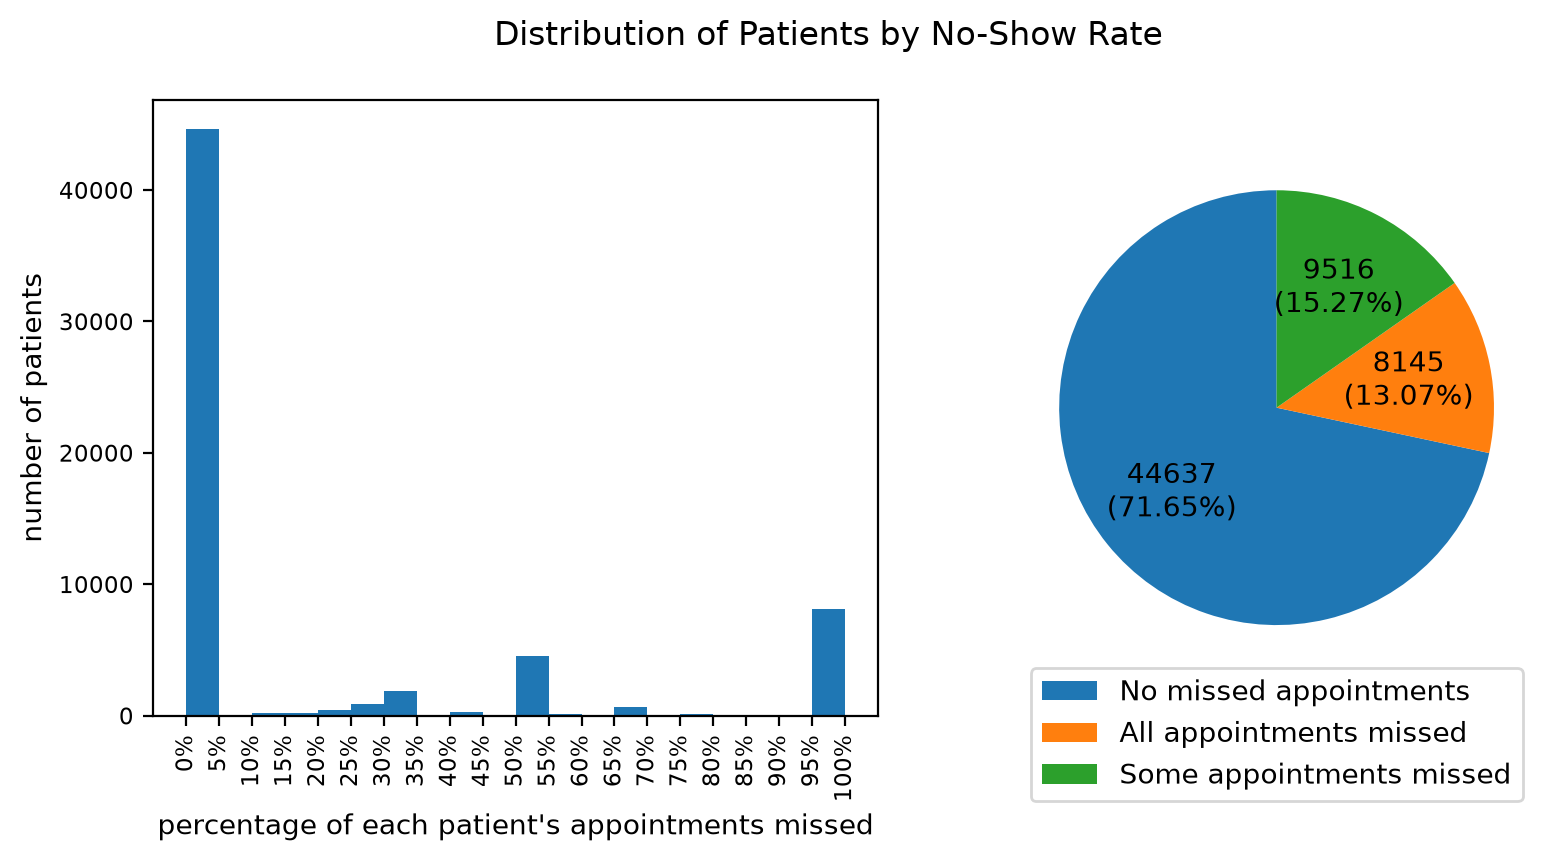

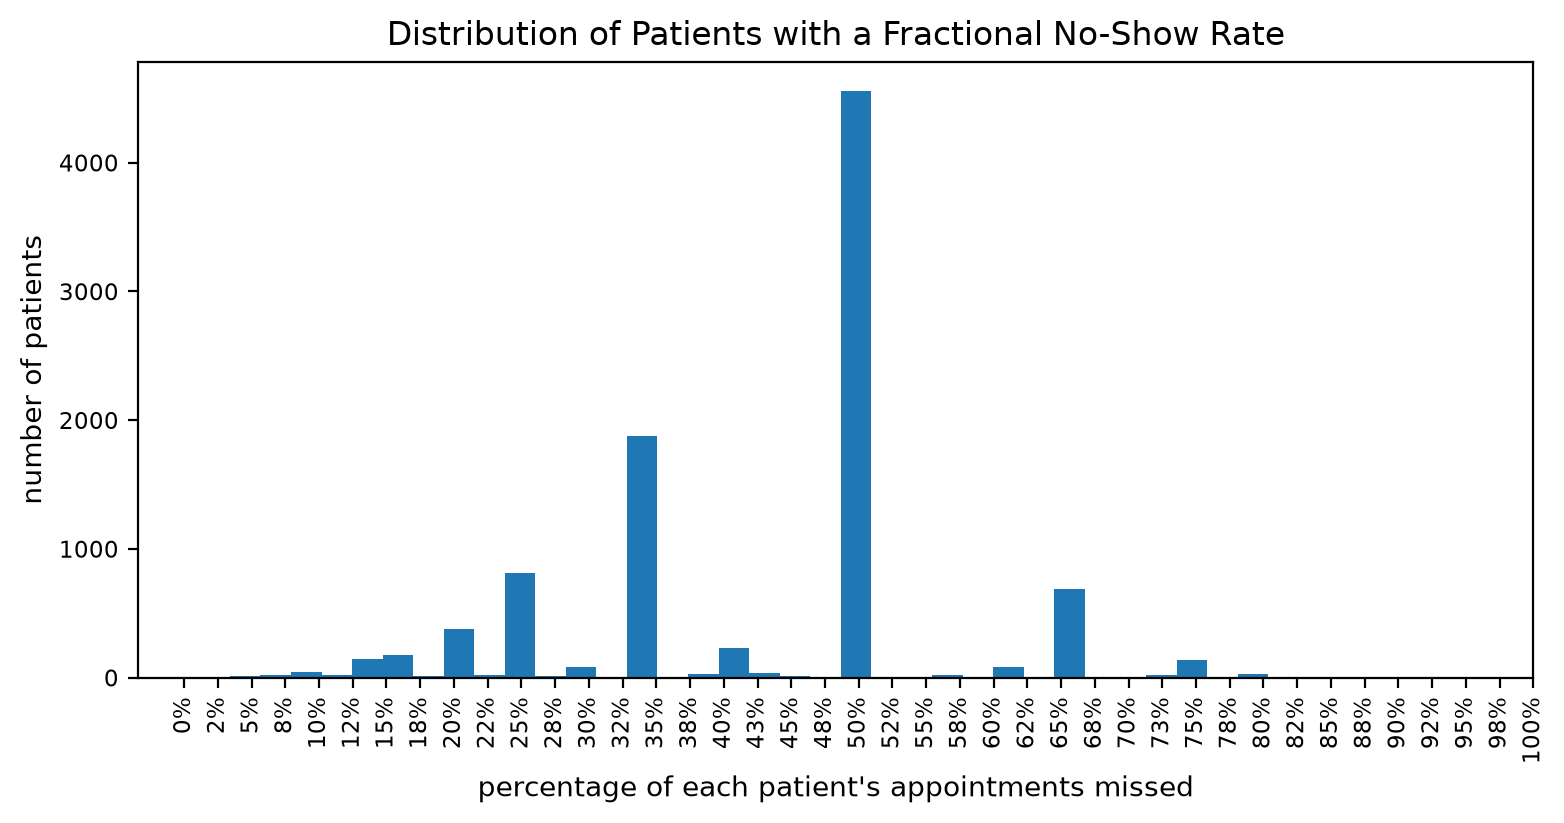

In [18]:
sns_fig, sns_axs = plt.subplots(
    1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [4, 3]}, constrained_layout=False
)

sns_fig.suptitle("Distribution of Patients by No-Show Rate")

# Plot p_NoShow distribution
p_NoShow_axs_bins = 20
p_NoShow_axs = df_all_patients["p_NoShow"].plot.hist(
    bins=p_NoShow_axs_bins,
    xlabel="percentage of each patient's appointments missed",
    ylabel="number of patients",
    ax=sns_axs[0],
)

xticks = np.linspace(0, 1, p_NoShow_axs_bins + 1)
xlabels = [f"{x*100:.0f}%" for x in xticks]
p_NoShow_axs.tick_params(labelsize="small")
p_NoShow_axs.tick_params("x", labelrotation=90)
p_NoShow_axs.set_xticks(xticks, labels=xlabels)

df_full_attendance = df_all_patients.query("p_NoShow == 0")
df_no_attendance = df_all_patients.query("p_NoShow == 1.0")
df_partial_attendance = df_all_patients.query("p_NoShow > 0 and p_NoShow < 1.0")
attendance_idx = [
    "No missed appointments",
    "All appointments missed",
    "Some appointments missed",
]
attendance = pd.Series(
    [
        df_full_attendance.shape[0],
        df_no_attendance.shape[0],
        df_partial_attendance.shape[0],
    ],
    index=attendance_idx,
)

attend_ax = attendance.plot.pie(
    startangle=90,
    autopct=lambda pct: f"{int(round(pct * attendance.sum() / 100)):d}\n({pct:.2f}%)",
    pctdistance=0.62,
    labels=None,
    ax=sns_axs[1],
)
attend_ax.legend(
    attend_ax.patches,
    attendance.index,
    ncols=1,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
)
plt.show()


# Plot distribution for patients with a fractional p_NoShow
p_NoShow_fns_axs_bins = 40
p_NoShow_fns_axs = df_partial_attendance["p_NoShow"].plot.hist(
    bins=p_NoShow_fns_axs_bins,
    xlabel="percentage of each patient's appointments missed",
    ylabel="number of patients",
    figsize=[9, 4],
)

p_NoShow_fns_axs.set_title("Distribution of Patients with a Fractional No-Show Rate")

fns_xticks = np.linspace(0, 1, p_NoShow_fns_axs_bins + 1)
fns_xlabels = [f"{x*100:.0f}%" for x in fns_xticks]
p_NoShow_fns_axs.tick_params(labelsize="small")
p_NoShow_fns_axs.tick_params("x", labelrotation=90)
p_NoShow_fns_axs.set_xticks(fns_xticks, labels=fns_xlabels)

plt.show()

In [19]:
print(df_partial_attendance["p_NoShow"].value_counts())

df_partial_attendance["p_NoShow"].describe()

p_NoShow
0.500000    4557
0.333333    1878
0.250000     813
0.666667     689
0.200000     373
            ... 
0.733333       1
0.550000       1
0.521739       1
0.533333       1
0.466667       1
Name: count, Length: 91, dtype: int64


count    9516.000000
mean        0.429983
std         0.142274
min         0.011364
25%         0.333333
50%         0.500000
75%         0.500000
max         0.916667
Name: p_NoShow, dtype: float64

#### Gender, Financial Assistance Program Enrollment, Hypertension, Diabetes, Alcoholism 
data: `Gender`, `FinancialAssistance`, `Hypertension`, `Diabetes`, `Alcoholism`

In this section we look into whether Gender, FinancialAssistance, Hypertension, Diabetes, or Alcoholism had a statistically significant association with missed appointments - individually or collectively.

##### Analysis Summary
There are no large skews in health and demographic factor distribution when comparing all patients to the set of 'likely no-show' patients

Of the factors analyzed here, OLS linear regression indicates that Financial Assistance and Alcoholism are associated with a small increase in patient no-show rate, while Hypertension is associated with a small decrease. The effect, however, is very weak; the model explains only about 0.3% of the variation in patient no-show behavior.

| significant predictor | p-value | coefficient |
| --- | --- | --- |
| FinancialAssistance | < 0.001 | +0.0309 |
| Hypertension | < 0.001 | -0.0433 |
| Alcoholism | < 0.001 | +0.0468 |

R-squared: 0.003



##### Analysis

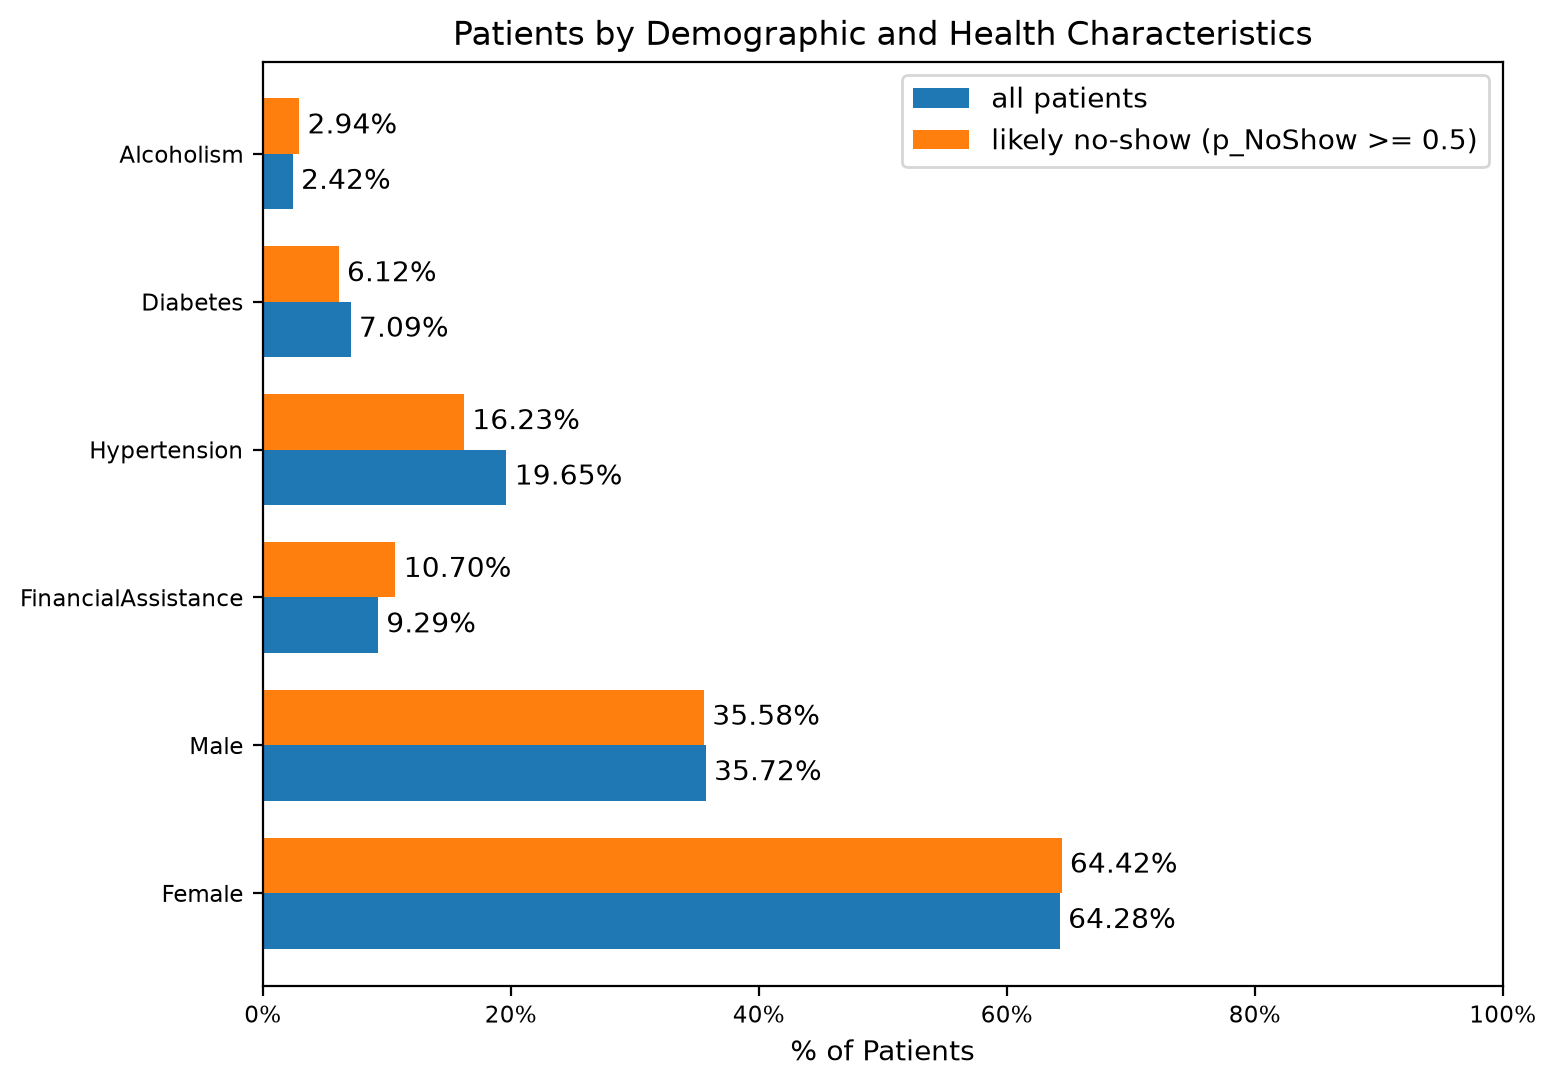

In [20]:
demo_sub_queries = {
    "Female": "female == 1",
    "Male": "male == 1",
    "FinancialAssistance": "FinancialAssistance == 1",
    "Hypertension": "Hypertension == 1",
    "Diabetes": "Diabetes == 1",
    "Alcoholism": "Alcoholism == 1",
}

ax_demo = graph_distributions(
    data=compute_distributions(
        data=df_all_patients,
        group_queries={
            "all patients": None,
            "likely no-show (p_NoShow >= 0.5)": no_show_query,
        },
        sub_queries=demo_sub_queries,
    ),
    x_label=x_axis_title,
)
ax_demo.set_title("Patients by Demographic and Health Characteristics")
plt.show()

In [21]:
demographics_ols_model = sm.OLS(
    df_all_patients["p_NoShow"],
    df_all_patients[
        [
            "intercept",
            "FinancialAssistance",
            "Hypertension",
            "Diabetes",
            "Alcoholism",
            "female",
        ]
    ],
)
demographics_ols_results = demographics_ols_model.fit()
demographics_ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               p_NoShow   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     42.34
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.05e-43
Time:                        16:03:18   Log-Likelihood:                -23141.
No. Observations:               62298   AIC:                         4.629e+04
Df Residuals:                   62292   BIC:                         4.635e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.2010      0.002     81.614      0.000       0.196       0.206
FinancialAssistance     0.0309      0.005      6.321      0.000       0.021       0.040
Hypertension           -0.0433      0.004    -11.009      0.000      -0.051      -0.036
Diabetes                0.0002      0.006      0.035      0.972      -0.012       0.012
Alcoholism              0.0468      0.009      5.070      0.000       0.029       0.065
female                 -0.0001      0.003     -0.046      0.963      -0.006       0.006
==============================================================================
Omnibus:                    14032.008   Durbin-Watson:                   1.800
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25594.991
Skew:                           1.525   Prob(JB):                         0.00
Kurtosis:                       3.747   Cond. No.                         8.19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
explanatory_variables(demographics_ols_results).style.format(precision=4).set_caption(
    "explanatory variables"
)

,p_value,coef
variable,,
FinancialAssistance,0.0000,0.0309
Hypertension,0.0000,-0.0433
Alcoholism,0.0000,0.0468


#### Neighborhood
data: `Neighborhood`

There are 81 neighborhoods recorded in the dataset. The number of patients per neighborhood varies significantly, from 1 to 4192 patients per neighborhood.

Neighborhoods with few patients produce imprecise no-show-rate estimates and large standard errors when using OLS. To reduce this problem, we will filter neighborhoods below a minimum patient threshold.

##### Caveats

__Many Neighborhoods__

- Due to large number of dummy variables, p-values may be noisy so this analysis should be seen an exploratory result rather than a definitive causal conclusion.

__Small Neighborhoods__

- Regressions were run using 50, 100, and 200 as the minimum patient threshold. Results were consistent across all three thresholds.
- For simplicity, the rest of this section will use a 100 patient threshold to illustrate the results. All three are referenced in the analysis summary.
- If needed, the threshold can be easily changed in the code block below and re-running the model.

In [23]:
min_patients = 100  # 50, 100, 200

# All Neighborhoods
nhood_NoShow = pd.concat(
    [
        df_all_patients.groupby("Neighborhood")["p_NoShow"].count(),
        df_all_patients.groupby("Neighborhood")["p_NoShow"].mean(),
    ],
    axis=1,
    keys=["num_patients", "p_NoShow mean"],
)

nhood_NoShow.sort_values("num_patients", ascending=False, inplace=True)

print("all neighborhoods:")
print(value_range(nhood_NoShow, "num_patients"))

all neighborhoods:
num_patients:
min     max
1       4192



In [24]:
# Small Neighborhoods
small_neighborhoods = nhood_NoShow.query("num_patients < @min_patients")
print(f"\nsmall neighborhoods (< {min_patients} patients):")

filter_list = small_neighborhoods.index.values

print(small_neighborhoods[["num_patients"]])
print(
    f"\n{len(small_neighborhoods)} small neighborhoods: {small_neighborhoods[['num_patients']].sum().values[0]} total patients"
)

df_all_patients_filtered = df_all_patients[
    ~df_all_patients["Neighborhood"].isin(filter_list)
]


small neighborhoods (< 100 patients):
                             num_patients
Neighborhood                             
UNIVERSITÁRIO                          93
SEGURANÇA DO LAR                       89
NAZARETH                               86
MORADA DE CAMBURI                      68
PONTAL DE CAMBURI                      45
ILHA DO BOI                            22
AEROPORTO                               7
ILHA DO FRADE                           5
ILHAS OCEÂNICAS DE TRINDADE             2
PARQUE INDUSTRIAL                       1

10 small neighborhoods: 418 total patients


##### Analysis Summary

Across minimum patient thresholds of 50, 100, and 200, the models consistently indicated an association between neighborhood and patient no-show rate. 

Using the 100 patient threshold, OLS linear regression indicates that 26 neighborhoods are statistically associated with no-show rates. 5 were associated with a decrease and 21 with an increase.

A joint F-test of Neighborhood as a whole reported a very low p-value, indicating a statistically significant association between patient no-show rate and Neighborhood as a whole. However, the effect is weak; the model explains only about 0.7% of the variation in patient no-show behavior.

| minimum patients | neighborhoods filtered | F-statistic | joint-test p-value | (R^2) |
| --- | --- | --- | --- | --- |
| 50 | 6 | 6.314 | 3.78e-58 | 0.007 |
| 100 | 10 | 6.609 | 6.29e-59 | 0.007 |
| 200 | 20 | 7.382 | 1.64e-59 | 0.007 |

##### Analysis

The largest neighborhood, in terms of number of patients, was selected as the reference category to provide a relatively stable comparison group.

In [25]:
# linear regression for neighborhood (all Patients)

# neighborhood with largest number of patients to be used as baseline
nhoods = df_all_patients_filtered["Neighborhood"].unique().tolist()
baseline_neighborhood = df_all_patients_filtered["Neighborhood"].value_counts().idxmax()
print(f"baseline neighborhood (most patients): {baseline_neighborhood}\n")

predictor_neighborhoods = []
for nhood in nhoods:
    if nhood != baseline_neighborhood:
        predictor_neighborhoods.append(nhood)

patient_nhood_model_OLS = sm.OLS(
    df_all_patients_filtered["p_NoShow"],
    df_all_patients_filtered[["intercept"] + predictor_neighborhoods],
)
patient_nhood_model_OLS_results = patient_nhood_model_OLS.fit()

patient_nhood_model_OLS_results.summary()

baseline neighborhood (most patients): JARDIM CAMBURI



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               p_NoShow   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     6.609
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           6.29e-59
Time:                        16:03:18   Log-Likelihood:                -22850.
No. Observations:               61880   AIC:                         4.584e+04
Df Residuals:                   61809   BIC:                         4.648e+04
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.1855      0.005     34.297      0.000       0.175       0.196
JARDIM DA PENHA        -0.0309      0.009     -3.445      0.001      -0.048      -0.013
MATA DA PRAIA          -0.0265      0.019     -1.422      0.155      -0.063       0.010
REPÚBLICA              -0.0369      0.017     -2.152      0.031      -0.071      -0.003
GOIABEIRAS             -0.0156      0.018     -0.855      0.393      -0.051       0.020
ANDORINHAS              0.0219      0.012      1.866      0.062      -0.001       0.045
CONQUISTA              -0.0079      0.017     -0.475      0.635      -0.040       0.025
NOVA PALESTINA         -0.0211      0.011     -1.938      0.053      -0.042       0.000
DA PENHA                0.0024      0.011      0.219      0.827      -0.019       0.024
TABUAZEIRO             -0.0148      0.010     -1.518      0.129      -0.034       0.004
BENTO FERREIRA          0.0299      0.017      1.792      0.073      -0.003       0.063
SÃO PEDRO               0.0188      0.011      1.714      0.087      -0.003       0.040
SANTA MARTHA           -0.0311      0.010     -3.117      0.002      -0.051      -0.012
SÃO CRISTÓVÃO           0.0073      0.012      0.615      0.538      -0.016       0.031
MARUÍPE                 0.0388      0.012      3.201      0.001       0.015       0.063
GRANDE VITÓRIA          0.0021      0.015      0.143      0.886      -0.027       0.031
SÃO BENEDITO           -0.0035      0.013     -0.266      0.790      -0.029       0.022
ILHA DAS CAIEIRAS       0.0324      0.016      2.065      0.039       0.002       0.063
SANTO ANDRÉ            -0.0212      0.011     -1.953      0.051      -0.043    7.47e-05
SOLON BORGES           -0.0196      0.022     -0.903      0.367      -0.062       0.023
BONFIM                  0.0162      0.010      1.577      0.115      -0.004       0.036
MARIA ORTIZ             0.0274      0.008      3.373      0.001       0.011       0.043
JABOUR                  0.0069      0.011      0.647      0.518      -0.014       0.028
ANTÔNIO HONÓRIO        -0.0224      0.027     -0.829      0.407      -0.075       0.031
RESISTÊNCIA             0.0043      0.009      0.482      0.630      -0.013       0.022
ILHA DE SANTA MARIA     0.0326      0.012      2.626      0.009       0.008       0.057
JUCUTUQUARA             0.0328      0.019      1.709      0.088      -0.005       0.070
MONTE BELO              0.0234      0.017      1.391      0.164      -0.010       0.056
MÁRIO CYPRESTE         -0.0230      0.025     -0.907      0.364      -0.073       0.027
SANTO ANTÔNIO          -0.0261      0.010     -2.572      0.010      -0.046      -0.006
BELA VISTA              0.0085      0.012      0.719      0.472      -0.015       0.032
PRAIA DO SUÁ            0.0458      0.014      3.355      0.001       0.019       0.072
SAN

__Significant Predictors__

Using the 100 patient threshold, OLS linear regression indicates that 26 neighborhoods are statistically associated with no-show rates.


In [26]:
nhood_sig_p = explanatory_variables(patient_nhood_model_OLS_results)

print(
    f"Excluding:\n{len(small_neighborhoods)} of the smallest neighborhoods (by patient count)\n{baseline_neighborhood}, which was used as the baseline"
)
print(
    f"\n{len(nhood_sig_p)} neighborhoods are statistically associated with no-show rates"
)

nhood_sig_p.style.format(precision=4).set_caption(
    f"nhood explanatory variables: >= {min_patients} patients"
)

Excluding:
10 of the smallest neighborhoods (by patient count)
JARDIM CAMBURI, which was used as the baseline

26 neighborhoods are statistically associated with no-show rates


,p_value,coef
variable,,
JARDIM DA PENHA,0.0006,-0.0309
REPÚBLICA,0.0314,-0.0369
SANTA MARTHA,0.0018,-0.0311
MARUÍPE,0.0014,0.0388
ILHA DAS CAIEIRAS,0.0389,0.0324
MARIA ORTIZ,0.0007,0.0274
ILHA DE SANTA MARIA,0.0086,0.0326
SANTO ANTÔNIO,0.0101,-0.0261
PRAIA DO SUÁ,0.0008,0.0458


In [27]:
# Test whether Neighborhood as a whole is associated with no-show rates
neighborhood_params = predictor_neighborhoods
parameter_names = patient_nhood_model_OLS_results.params.index

R = np.zeros((len(neighborhood_params), len(parameter_names)))

for row, neighborhood in enumerate(neighborhood_params):
    R[row, parameter_names.get_loc(neighborhood)] = 1

joint_test = patient_nhood_model_OLS_results.f_test(R)
print(f"minimum patient threshold: {min_patients}")
print(joint_test)

minimum patient threshold: 100
<F test: F=6.608717271055314, p=6.2890691654015765e-59, df_denom=6.18e+04, df_num=70>


#### Patient Age
data: `Age`

##### Analysis Summary

A scatter plot of Age distribution by p_NoShow reveals no obvious correlation pattern.

Viewing the data in buckets of "likely no-show" and "likely show", patients classified as "likely no-show" have a slightly lower median age than those classified as "likely show"

| | count | mean | std | min | 25% | 50% | 75% | max |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| All Patients | 62298 | 36.7055 | 23.5311 | 0.0 | 17.0 | _36.0_ | 56.0 | 115.0 | 
| p_NoShow >= 0.5 | 13713 | 33.6264 | 22.1186 | 0.0 | 16.0 | _32.0_ | 51.0 | 115.0 | 
| p_NoShow < 0.5 | 48585 | 37.5746 | 23.8430 | 0.0 | 17.0 | _38.0_ | 57.0 | 115.0 | 

OLS linear regression indicates that Age is associated with a very small decrease in no-show rates. The effect, however, is very weak; the model explains only about 0.5% of the variation in patient no-show behavior.

| predictor | p-value | coefficient |
| --- | --- | --- |
| Age | < 0.001 | -0.0010 |

R-squared: 0.005

##### Analysis

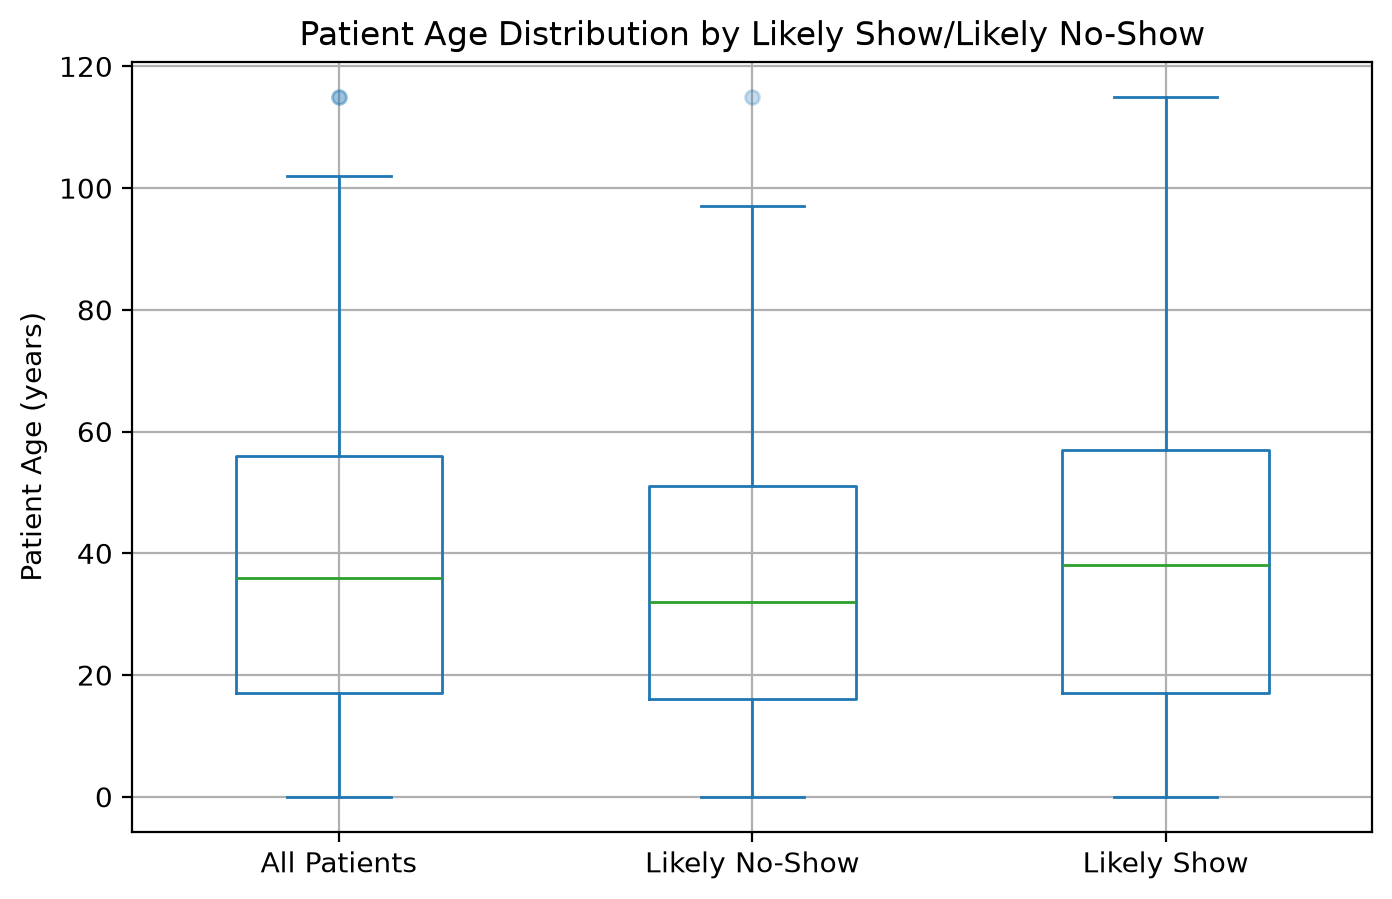

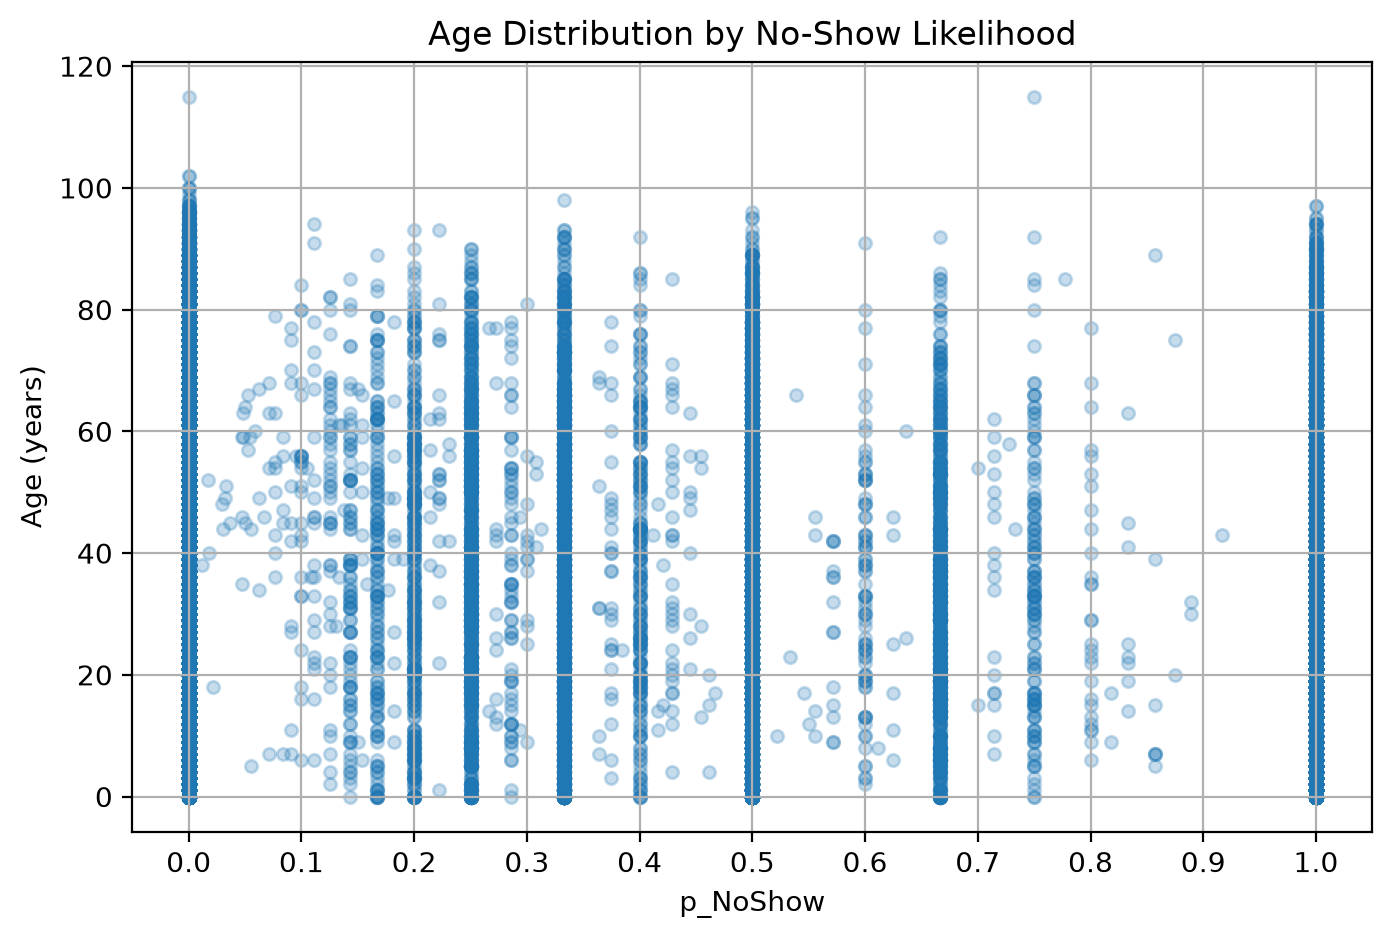

,count,mean,std,min,25%,50%,75%,max
All Patients,62298.0000,36.7055,23.5311,0.0000,17.0000,36.0000,56.0000,115.0000
p_NoShow >= 0.5,13713.0000,33.6264,22.1186,0.0000,16.0000,32.0000,51.0000,115.0000
p_NoShow < 0.5,48585.0000,37.5746,23.8430,0.0000,17.0000,38.0000,57.0000,115.0000


In [28]:
df_age_all = df_all_patients["Age"]
df_age_no_show = df_all_patients.query("p_NoShow >= 0.5")["Age"]
df_age_show = df_all_patients.query("p_NoShow < 0.5")["Age"]

df_age_dist = pd.DataFrame(
    {
        "All Patients": df_age_all,
        "Likely No-Show": df_age_no_show,
        "Likely Show": df_age_show,
    }
)

ax_age_box = df_age_dist.plot.box(
    figsize=[8, 5],
    grid=True,
    widths=0.5,
    flierprops={
        "marker": "o",
        "markerfacecolor": "tab:blue",
        "markeredgecolor": "tab:blue",
        "markersize": 5,
        "alpha": 0.25,
    },
)
ax_age_box.set_title("Patient Age Distribution by Likely Show/Likely No-Show")
ax_age_box.set_ylabel("Patient Age (years)")
plt.show()

ax_age_scatter = df_all_patients.plot.scatter(
    y="Age", x="p_NoShow", figsize=[8, 5], alpha=0.25, grid=True
)
ax_age_scatter.set_title("Age Distribution by No-Show Likelihood")
ax_age_scatter.set_ylabel("Age (years)")
ax_age_scatter.set_xticks(np.linspace(0, 1, 11))
plt.show()

age_all_describe = df_age_all.describe()
age_no_show_describe = df_age_no_show.describe()
age_show_describe = df_age_show.describe()

df_age_describe = pd.DataFrame(
    {
        "All Patients": age_all_describe,
        "p_NoShow >= 0.5": age_no_show_describe,
        "p_NoShow < 0.5": age_show_describe,
    }
)

df_age_describe.T.style.format(precision=4).set_caption("patient age distribution")

In [29]:
# linear regression
patient_age_model_OLS = sm.OLS(
    df_all_patients["p_NoShow"], df_all_patients[["intercept", "Age"]]
)

patient_age_model_OLS_results = patient_age_model_OLS.fit()
patient_age_model_OLS_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               p_NoShow   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     307.5
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.12e-68
Time:                        16:03:19   Log-Likelihood:                -23093.
No. Observations:               62298   AIC:                         4.619e+04
Df Residuals:                   62296   BIC:                         4.621e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2348      0.003     90.240      0.000       0.230       0.240
Age           -0.0010   5.97e-05    -17.536      0.000      -0.001      -0.001
==============================================================================
Omnibus:                    13975.748   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25436.930
Skew:                           1.520   Prob(JB):                         0.00
Kurtosis:                       3.743   Cond. No.                         80.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Number of Reported Handicaps
data: `NumHandicaps`

Although `NumHandicaps` is numeric, there are only a few discrete values in the dataset (0–4). Modeling it as a numeric predictor would assume that each additional reported handicap is associated with the same change in a patient's no-show rate. Instead, we will treat it as categorical broken down into dummy variables, with 0 handicaps as the reference group, so each count can have a separate association with no-show rate.


##### Caveats

There are a very low number of patients with > 1 handicap (108 out of 62298 patients). This could be affecting the quality of the results from regression models.

##### Analysis Summary

The vast majority of patients report 0 handicaps (98.18%).

OLS linear regression indicates that a count of 1 handicap is statistically associated with a decrease in no-show rates.

| significant predictor | p-value | coefficient |
| --- | --- | --- |
| NumHandicaps: 1 | < 0.001 | -0.0424 |

A joint F-test of NumHandicaps as a whole reported a very low p-value, indicating a statistically significant association between patient no-show and NumHandicaps. However, with a 0.000(rounded) R-squared value, the indicated effect is very weak.

| F-statistic | joint-test p-value | (R^2) |
| --- | --- | --- |
| 4.057 | 2.73-e3 | 0.000 (rounded) |

Due to the sparse data for patients with >= 1 handicap, the results should be interpreted cautiously.


##### Analysis

In [30]:
# convert NumHandicaps to categorical (0 - 4) and create dummies for linear regression modeling
print(df_all_patients["NumHandicaps"].value_counts())

num_handicaps_categories = df_all_patients["NumHandicaps"].unique()
num_handicaps_category = pd.api.types.CategoricalDtype(
    ordered=True, categories=num_handicaps_categories
)
df_all_patients["NumHandicaps"] = df_all_patients["NumHandicaps"].astype(
    num_handicaps_category
)
num_handicaps_dummies = pd.get_dummies(
    df_all_patients["NumHandicaps"], dtype=np.int8, prefix="nhcap"
)
df_all_patients = df_all_patients.join(num_handicaps_dummies)

NumHandicaps
0    61165
1     1025
2       99
3        6
4        3
Name: count, dtype: int64


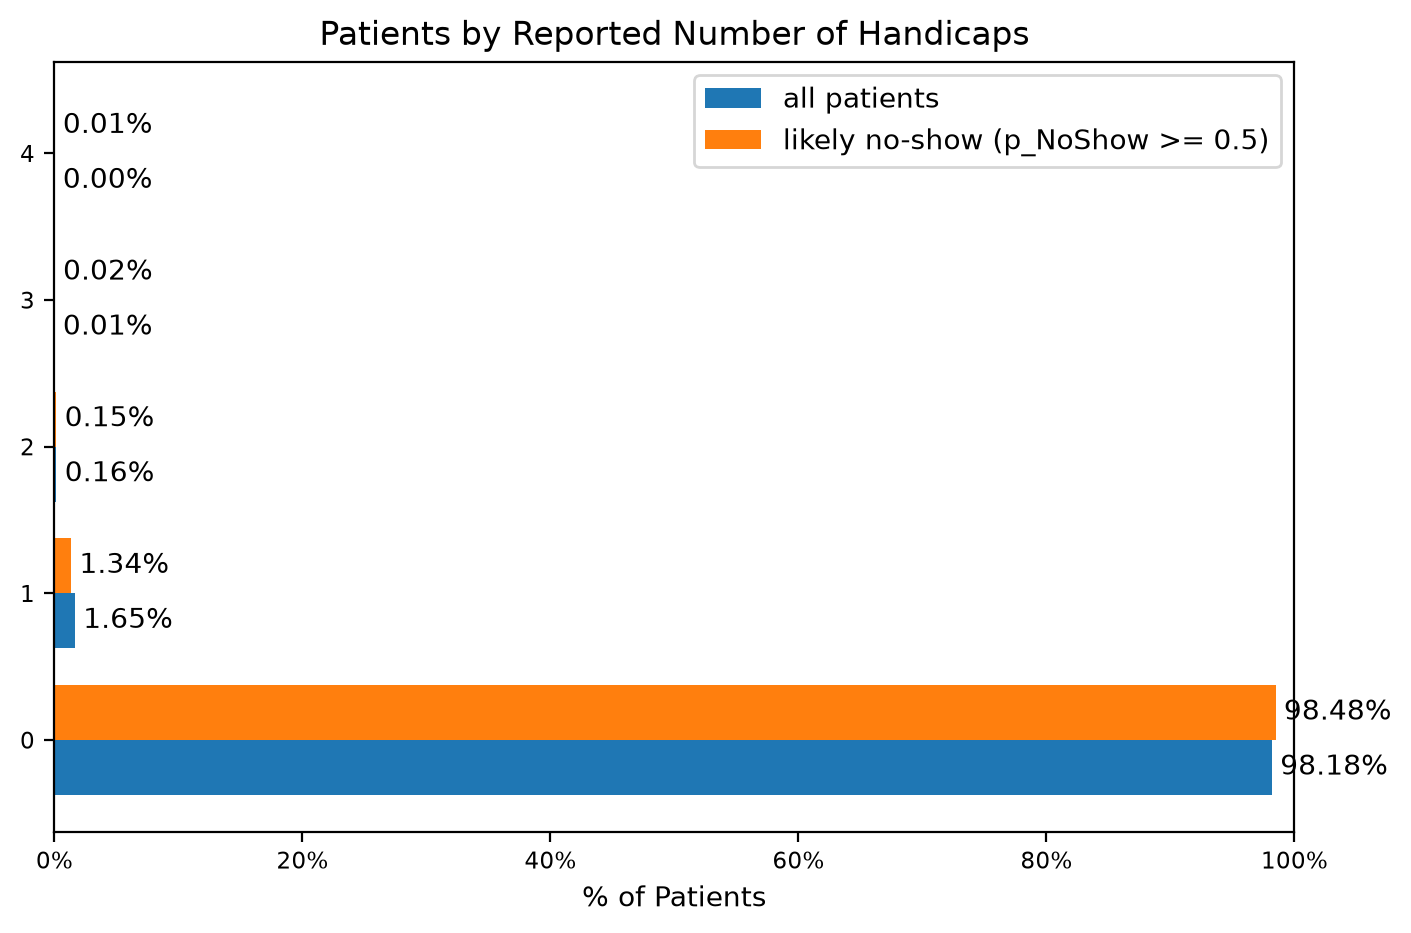

In [31]:
nhcaps_sub_queries = {
    "0": "nhcap_0 == 1",
    "1": "nhcap_1 == 1",
    "2": "nhcap_2 == 1",
    "3": "nhcap_3 == 1",
    "4": "nhcap_4 == 1",
}

ax_nhcaps = graph_distributions(
    data=compute_distributions(
        data=df_all_patients,
        group_queries={
            "all patients": None,
            "likely no-show (p_NoShow >= 0.5)": no_show_query,
        },
        sub_queries=nhcaps_sub_queries,
    ),
    x_label=x_axis_title,
)

ax_nhcaps.set_title("Patients by Reported Number of Handicaps")
plt.show()

In [32]:
# 0 handicaps used as baseline
nhcaps_ols_model = sm.OLS(
    df_all_patients["p_NoShow"],
    df_all_patients[["intercept", "nhcap_1", "nhcap_2", "nhcap_3", "nhcap_4"]],
)

nhcaps_ols_results = nhcaps_ols_model.fit()
nhcaps_ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               p_NoShow   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.057
Date:                Tue, 06 Oct 2026   Prob (F-statistic):            0.00273
Time:                        16:03:19   Log-Likelihood:                -23239.
No. Observations:               62298   AIC:                         4.649e+04
Df Residuals:                   62293   BIC:                         4.653e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1971      0.001    138.744      0.000       0.194       0.200
nhcap_1       -0.0424      0.011     -3.828      0.000      -0.064      -0.021
nhcap_2       -0.0169      0.035     -0.479      0.632      -0.086       0.052
nhcap_3        0.1362      0.143      0.949      0.342      -0.145       0.417
nhcap_4        0.1362      0.203      0.671      0.502      -0.261       0.534
==============================================================================
Omnibus:                    14098.280   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25784.564
Skew:                           1.531   Prob(JB):                         0.00
Kurtosis:                       3.748   Cond. No.                         144.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
explanatory_variables(nhcaps_ols_results).style.format(precision=4).set_caption(
    "explanatory variables"
)

,p_value,coef
variable,,
nhcap_1,0.0001,-0.0424


In [34]:
# Test whether NumHandicaps as a whole is associated with no-show rates
# neighborhood_params = predictor_neighborhoods
num_hcap_params = ["nhcap_1", "nhcap_2", "nhcap_3", "nhcap_4"]
num_hcap_parameter_names = nhcaps_ols_results.params.index

R = np.zeros((len(num_hcap_params), len(num_hcap_parameter_names)))

for row, num_hcap in enumerate(num_hcap_params):
    R[row, num_hcap_parameter_names.get_loc(num_hcap)] = 1

joint_test = nhcaps_ols_results.f_test(R)
print(joint_test)

<F test: F=4.057108585438545, p=0.0027297185093397634, df_denom=6.23e+04, df_num=4>


#### Question 1: Conclusions

Several patient demographic and health factors were identified as having some association with a change in a patient's p_NoShow value; both positive and negative. R-squared values were, however, consistently very low so they have limited explanatory power.

Caveats:

- Some categories with sparse data (low patient count neighborhoods and occurences of NumHandicap values >= 1) should be interpreted cautiously.
- Interactions between factors were not tested and could be explored in future analysis.

In conclusion, no single demographic or health factor was identified in this analysis that has strong explanatory power for patient no-show rates.

<a id='question2'></a>
### Question 2: Do any data points related to logistical information about the appointment show a corelation with the likelihood an appointment will be missed?

#### Appointment factors for analysis
- `SchedulingDate_day_name` - day of week
- `AppointmentDate_day_name` - day of week
- `num_days` - number of days between `SchedulingDate` and `AppointmentDate`
- `SMS_received` - was an SMS reminder sent to the patient for the appointment?

#### Show/No-Show distribution across all appointments
data: `NoShow`

Of 110,521 appointments, most were attended by the patient: 88,207 (79.81%). 22,314 (20.19%) appointments were marked as no-show.

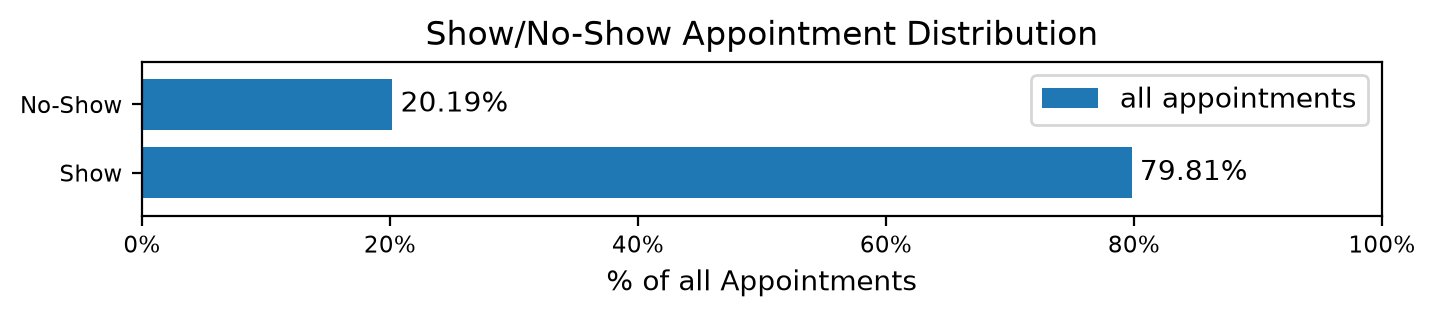

In [35]:
ax_all_appointments = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments,
        group_queries={
            "all appointments": None,
        },
        sub_queries={
            "Show": "NoShow == False",
            "No-Show": "NoShow == True"
        }
    ),
    x_label="% of all Appointments"
)
ax_all_appointments.set_title("Show/No-Show Appointment Distribution")

plt.show()

In [36]:
no_show_counts = df_all_appointments["NoShow"].value_counts()

print("Appointment Counts")
print(f"{'all:':<8}{df_all_appointments.shape[0]:>8}")
print(f"{'no-show:':<8}{no_show_counts[1]:>8}")
print(f"{'show:':<8}{no_show_counts[0]:>8}")

Appointment Counts
all:      110521
no-show:   22314
show:      88207


#### Scheduling and Appointment Day of Week
data: `SchedulingDate_day_name`, `AppointmentDate_day_name`

##### Analysis Summary

Most appointments were both scheduled and attended on weekdays, with a very small fraction on Saturday and none on Sunday.

Comparing the scheduling and appointment days of week for No-Show appointments to all appointments, no obvious skews are observed in the graphs.

Logistic regression for Scheduling day of week (`SchedulingDate_day_name`) indicated Friday has a positive association with appointment no-show when compared to Monday (the chosen baseline). However, a joint test of `SchedulingDate_day_name` returned a p-value of 0.0633, indicating the factor as a whole doesn't have a statistically significant association with `NoShow` values.

| predictor | p-value | coefficient |
| --- | --- | --- |
| `sch_Friday` | 0.0441 | +0.0492 |
| `SchedulingDate_day_name` | 0.0633 |  |

Logistic regression for Appointment day of week (`AppointmentDate_day_name`) indicates Wednesday and Thursday have a negative association with appointment no-show compared to Monday (the chosen baseline). A joint test of `AppointmentDate_day_name` returned a < 0.0001 p-value, indicating the factor as a whole also has a statistically significant association with `NoShow` values.

| predictor | p-value | coefficient |
| --- | --- | --- |
| `apt_Wednesday` | 0.0086 | -0.0595 |
| `apt_Thursday` | 0.0014 | -0.0810 |
| `AppointmentDate_day_name` | < 0.001  |  |


##### Analysis

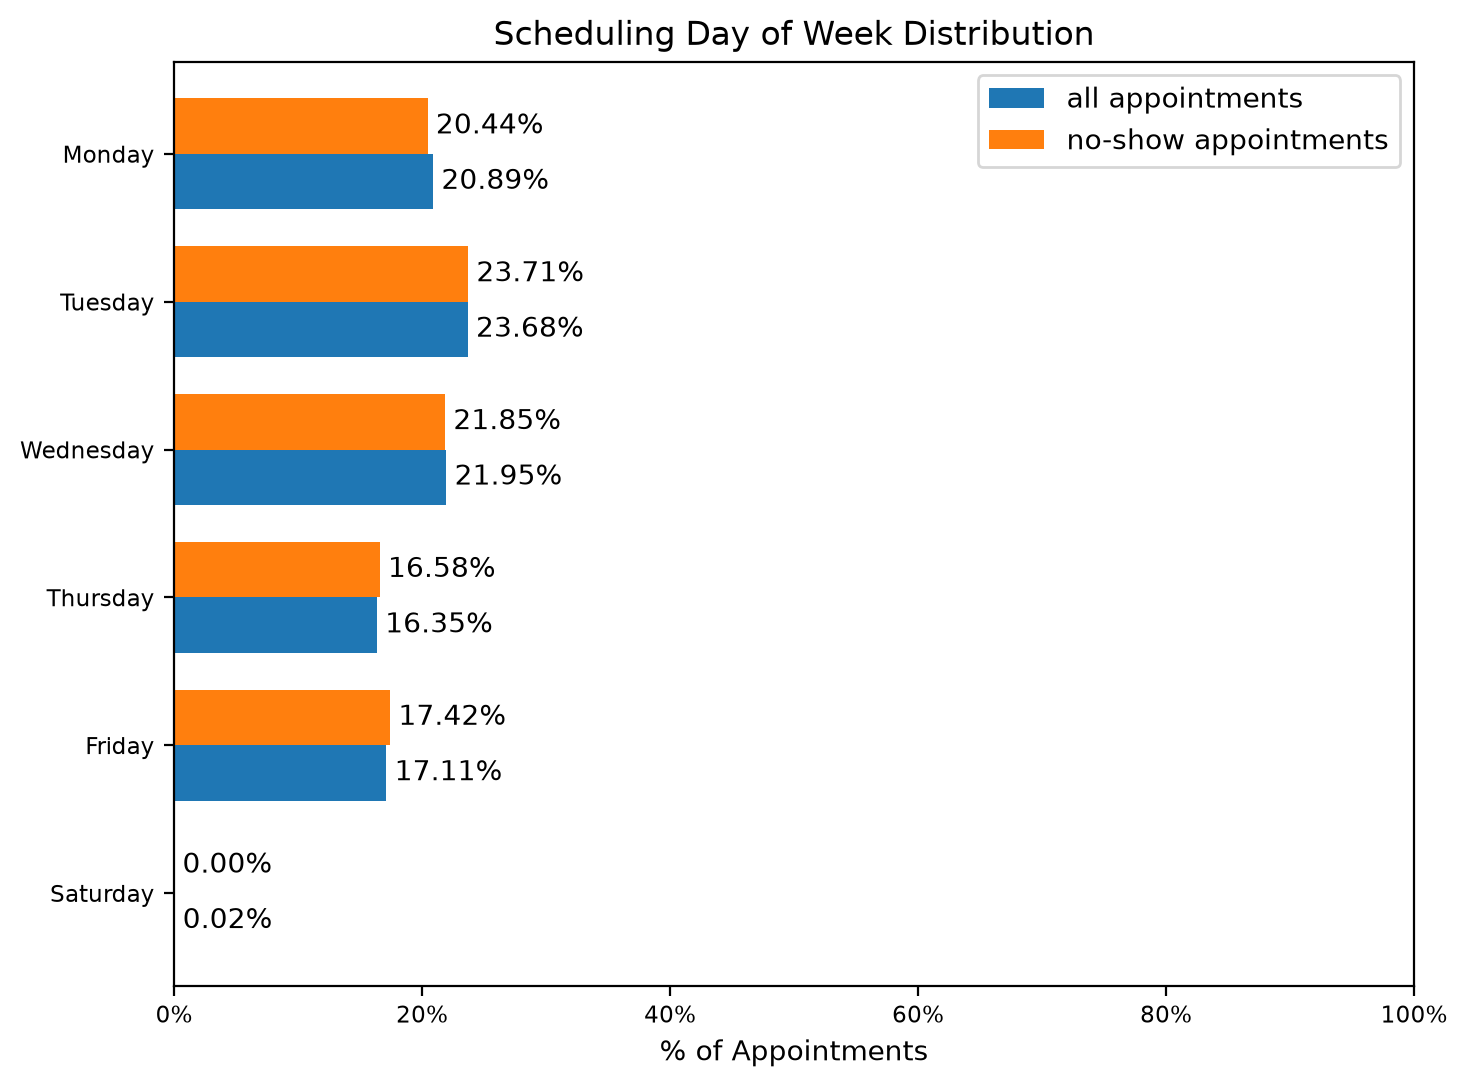

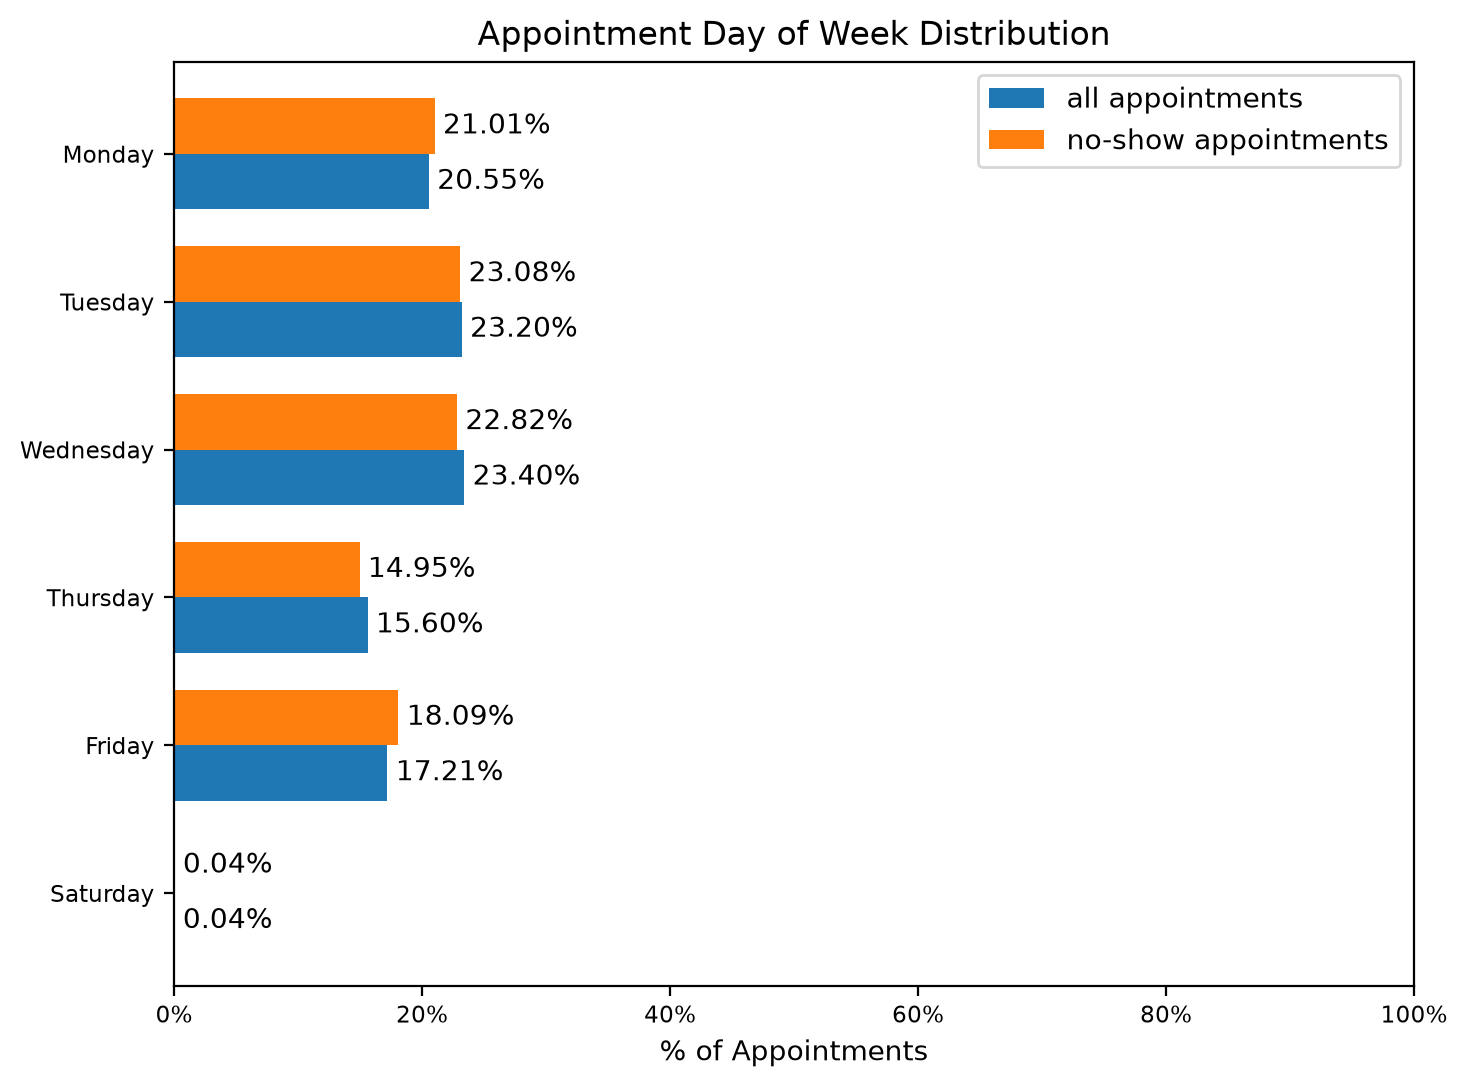

In [37]:
sch_day_sub_queries = {
    "Saturday": "sch_Saturday == 1",
    "Friday": "sch_Friday == 1",
    "Thursday": "sch_Thursday == 1",
    "Wednesday": "sch_Wednesday == 1",
    "Tuesday": "sch_Tuesday == 1",
    "Monday": "sch_Monday == 1",
}

ax_sch_day_all = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments,
        group_queries={
            "all appointments": None,
            "no-show appointments": "NoShow == True",
        },
        sub_queries=sch_day_sub_queries,
    ),
    x_label="% of Appointments",
)
ax_sch_day_all.set_title("Scheduling Day of Week Distribution")

plt.show()

apt_day_sub_queries = {
    "Saturday": "apt_Saturday == 1",
    "Friday": "apt_Friday == 1",
    "Thursday": "apt_Thursday == 1",
    "Wednesday": "apt_Wednesday == 1",
    "Tuesday": "apt_Tuesday == 1",
    "Monday": "apt_Monday == 1",
}

ax_apt_day_all = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments,
        group_queries={
            "all appointments": None,
            "no-show appointments": "NoShow == True",
        },
        sub_queries=apt_day_sub_queries,
    ),
    x_label="% of Appointments",
)
ax_apt_day_all.set_title("Appointment Day of Week Distribution")
plt.show()

In [38]:
# logistic regression: schedule days
# baseline for SchedulingDate_day_name dummies: Monday (Sunday is not present in data)
schedule_day_model = sm.Logit(
    df_all_appointments["NoShow"],
    df_all_appointments[
        [
            "intercept",
            #"sch_Monday",
            "sch_Tuesday",
            "sch_Wednesday",
            "sch_Thursday",
            "sch_Friday",
            "sch_Saturday",
        ]
    ],
)
schedule_day_results = schedule_day_model.fit()


# logistic regression: appointment days
# baseline for AppointmentDate_day_name: Monday (Sunday is not present in data)
appointment_day_model = sm.Logit(
    df_all_appointments["NoShow"],
    df_all_appointments[
        [
            "intercept",
            #"apt_Monday",
            "apt_Tuesday",
            "apt_Wednesday",
            "apt_Thursday",
            "apt_Friday",
            "apt_Saturday",
        ]
    ],
)
appointment_day_results = appointment_day_model.fit()

Optimization terminated successfully.
         Current function value: 0.502975
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.502898
         Iterations 5


In [39]:
# Schedule Day of Week results

print(schedule_day_results.summary())
print(f"\nSchedulingDate_day_name joint test p-value: {schedule_day_results.llr_pvalue:.6f}")
explanatory_variables(schedule_day_results).style.format(precision=4).set_caption(
    "explanatory variables"
)

                           Logit Regression Results                           
Dep. Variable:                 NoShow   No. Observations:               110521
Model:                          Logit   Df Residuals:                   110515
Method:                           MLE   Df Model:                            5
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:               9.404e-05
Time:                        16:03:19   Log-Likelihood:                -55589.
converged:                       True   LL-Null:                       -55595.
Covariance Type:            nonrobust   LLR p-value:                   0.06329
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        -1.4015      0.017    -84.784      0.000      -1.434      -1.369
sch_Tuesday       0.0286      0.023      1.268      0.205      -0.016       0.073
sch_Wednesday     0.0214      0.023     

,p_value,coef
variable,,
sch_Friday,0.0441,0.0492


In [40]:
# Appointment Day of Week results
print(appointment_day_results.summary())
print(f"\nAppointmentDate_day_name joint test p-value: {appointment_day_results.llr_pvalue:.6f}")
explanatory_variables(appointment_day_results).style.format(precision=4).set_caption(
    "explanatory variables"
)


                           Logit Regression Results                           
Dep. Variable:                 NoShow   No. Observations:               110521
Model:                          Logit   Df Residuals:                   110515
Method:                           MLE   Df Model:                            5
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:               0.0002475
Time:                        16:03:19   Log-Likelihood:                -55581.
converged:                       True   LL-Null:                       -55595.
Covariance Type:            nonrobust   LLR p-value:                 4.521e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        -1.3465      0.016    -82.135      0.000      -1.379      -1.314
apt_Tuesday      -0.0344      0.023     -1.519      0.129      -0.079       0.010
apt_Wednesday    -0.0595      0.023     

,p_value,coef
variable,,
apt_Wednesday,0.0086,-0.0595
apt_Thursday,0.0014,-0.0810


#### Number of Days Between Scheduling and Visit
data: `num_days`

##### Analysis Summary

The number of days (num_days) between scheduling and the visit tends to be longer for no-show appointments than for show appointments. The mean is more than 7 days longer for no-show appointments (15.8 days) than for show appointments (8.8 days), while the median is 9 days longer (11 vs 2 days).

|  | mean | median |
| --- | --- | --- |
| All Appointments | 10.1843 | 4.0000 |
| No-Show | 15.8355 | 11.0000 |
| Show | 8.7548	| 2.0000 |

A logistic regression model's coefficient for num_days indicates that longer gaps between scheduling and the visit are statistically associated with a higher likelihood of an appointment being a "no-show".

| p-value | coefficient |
| --- | --- |
| < 0.001 | +0.0259 |

##### Analysis

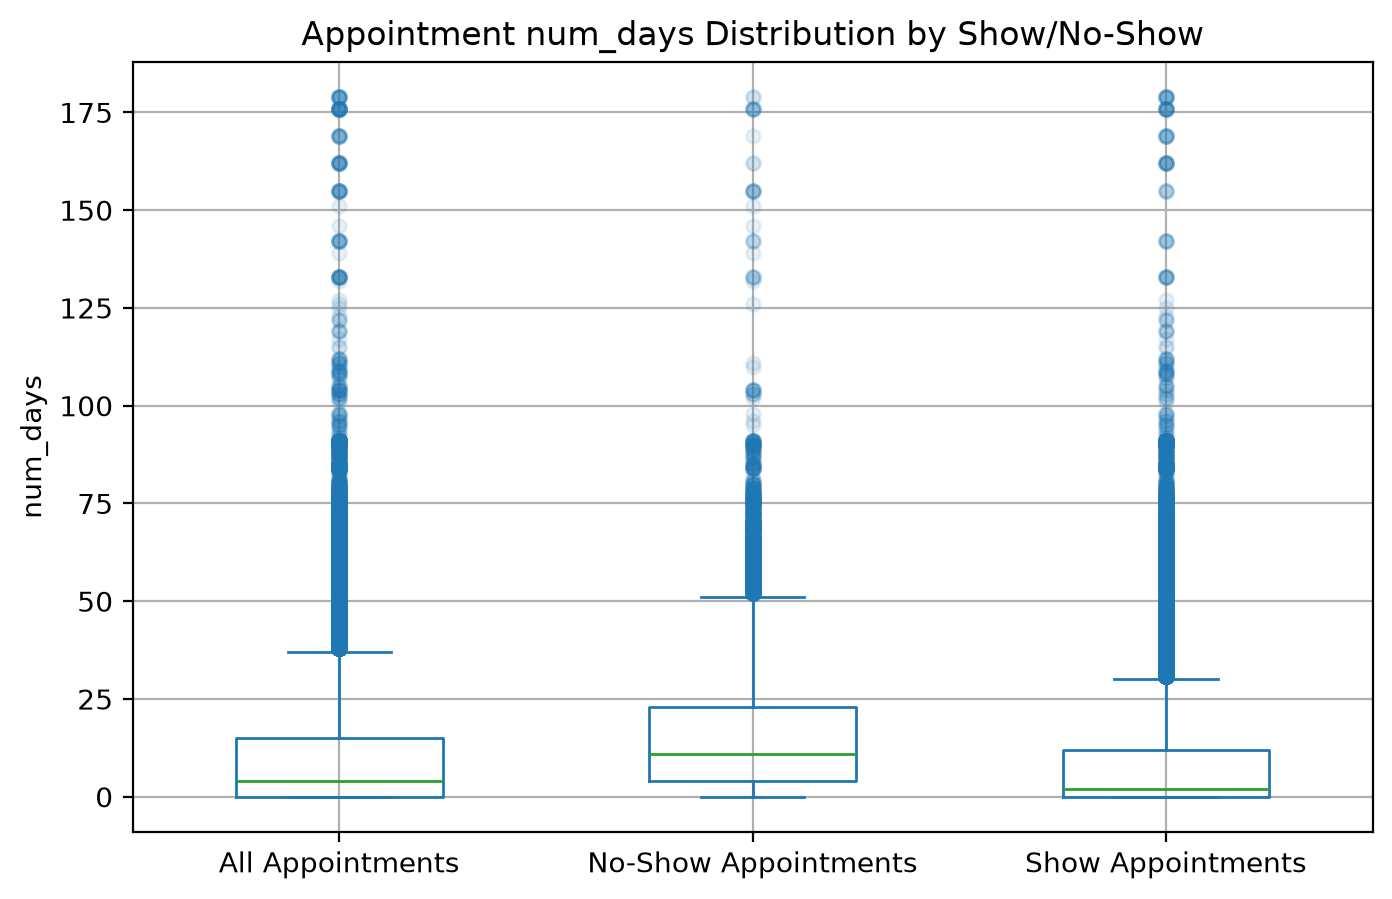

,count,mean,std,min,25%,50%,75%,max
All Appointments,110521.0000,10.1843,15.2552,0.0000,0.0000,4.0000,15.0000,179.0000
No-Show,22314.0000,15.8355,16.6056,0.0000,4.0000,11.0000,23.0000,179.0000
Show,88207.0000,8.7548,14.5505,0.0000,0.0000,2.0000,12.0000,179.0000


In [41]:
df_num_days_all = df_all_appointments["num_days"]
df_num_days_no_show = df_all_appointments.query("NoShow == True")["num_days"]
df_num_days_show = df_all_appointments.query("NoShow == False")["num_days"]

df_num_days_dist = pd.DataFrame(
    {
        "All Appointments": df_num_days_all,
        "No-Show Appointments": df_num_days_no_show,
        "Show Appointments": df_num_days_show,
    }
)

# box plot
ax_num_days_box = df_num_days_dist.plot.box(
    figsize=[8, 5],
    grid=True,
    widths=0.5,
    flierprops={
        "marker": "o",
        "markerfacecolor": "tab:blue",
        "markeredgecolor": "tab:blue",
        "markersize": 5,
        "alpha": 0.1,
    },
)
ax_num_days_box.set_title("Appointment num_days Distribution by Show/No-Show")
ax_num_days_box.set_ylabel("num_days")
plt.show()

num_days_all_describe = df_num_days_all.describe()
num_days_no_show_describe = df_num_days_no_show.describe()
num_days_show_describe = df_num_days_show.describe()

df_num_days_describe = pd.DataFrame(
    {
        "All Appointments": num_days_all_describe,
        "No-Show": num_days_no_show_describe,
        "Show": num_days_show_describe,
    }
)

df_num_days_describe.T.style.format(precision=4).set_caption(
    "appointment num_days distribution"
)

In [42]:
# logistic regression for num_days
num_days_model = sm.Logit(
    df_all_appointments["NoShow"], df_all_appointments[["intercept", "num_days"]]
)
num_days_results = num_days_model.fit()

print(num_days_results.summary())

print(f"explanatory variables\n{explanatory_variables(num_days_results)}")

Optimization terminated successfully.
         Current function value: 0.487885
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 NoShow   No. Observations:               110521
Model:                          Logit   Df Residuals:                   110519
Method:                           MLE   Df Model:                            1
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:                 0.03009
Time:                        16:03:20   Log-Likelihood:                -53922.
converged:                       True   LL-Null:                       -55595.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.6779      0.010   -175.079      0.000      -1.697      -1.659
num_days       0.0259      0.

#### SMS Reminder Message
data: `SMS_received`

##### Analysis Summary

__SMS_received Distribution__

67.90% of all appointments did not include an SMS reminder message to the patient. However, 34.89% of all appointments were same-day, where an SMS reminder message would be of little utility. Indeed, the data shows that no SMS messages were sent for any same-day appointment.

Therefore, in our analysis of associations between SMS_received and NoShow we filtered out same-day appointments from our model.

|  | # of appointments | % of all appointments |
| --- | --- | --- |
| All | 110521 | 100% |
| All, SMS received | 35482 | 32.10% |
| All, no SMS | 75039 | 67.90% |
| All, Same-day | 38562 | 34.89% |
| Same-day, SMS received | 0 | 0% |
| Same-day, no SMS | 38562 | 34.89% |

__NoShow and SMS_received__

Excluding same-day, when an SMS message was sent, 27.57% of appointments were no-show vs 29.44% when no SMS message was sent - a 1.87% difference in no-show rate.

Additionally, a logistic regression model's coefficient for SMS_received indicates that an SMS reminder message is statistically associated with a lower odds of an appointment being a "no-show"

| p-value | coefficient |
| --- | --- |
| < 0.001 | -0.0914 |

__Appointment num_days Distribution by SMS_received__

A cursory investigation was done looking for hints at a relationship between SMS reminder message, Show/No-Show and appointment lead time. 

Average lead time for 'show' appointments was 18.64 days when accompanied by an SMS reminder and 11.39 days when no SMS message was sent; an increase of 7.25 days. This may be evidence that an SMS reminder is associated with the show/no-show likelihood for appointments with longer lead times. However, this will require a more thorough analysis than was done here before any relationship can be confidently reported.

__Appointment: No-Show__
| NoShow == True | mean num_days | median num_days |
| --- | --- | --- |
| SMS | 20.00 | 15 |
| No SMS | 14.68 | 9 |
| diff w/SMS | +5.32 days | +6 days |

__Appointment: Show__
| NoShow == False | mean num_days | median num_days |
| --- | --- | --- |
| SMS | 18.64 | 14 |
| No SMS | 11.39 | 5 |
| diff w/SMS | +7.25 days | +9 days |


##### Analysis

__SMS_received Distribution and Same-Day Appointments__

All appointments    110521
All SMS_received    35482
All No SMS          75039


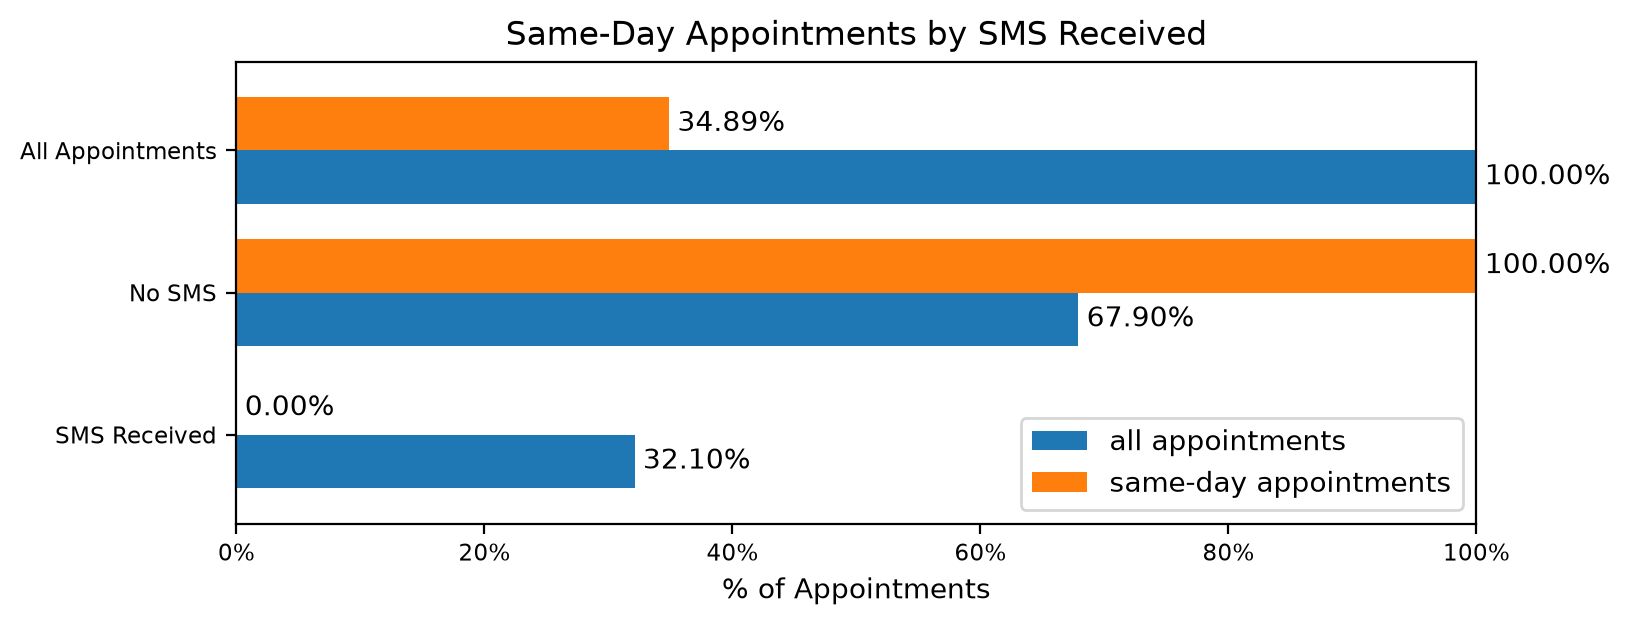

In [43]:
df_same_day_appointments = df_all_appointments.query("num_days == 0")

print(f"{'All appointments':<20}{df_all_appointments.shape[0]}")
print(
    f"{'All SMS_received':<20}{df_all_appointments.query('SMS_received == True').shape[0]}"
)
print(
    f"{'All No SMS':<20}{df_all_appointments.query('SMS_received == False').shape[0]}"
)

ax_same_day = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments,
        group_queries={
            "all appointments": None,
            "same-day appointments": "num_days == 0",
        },
        sub_queries={
            "SMS Received": "SMS_received == True",
            "No SMS": "SMS_received == False",
            "All Appointments": None,
        },
    ),
    x_label="% of Appointments",
    legend_loc="lower right",
)
ax_same_day.set_title("Same-Day Appointments by SMS Received")
plt.show()

__NoShow and SMS_Received__


Same day
All                 38562
SMS_received        0
No SMS              38562


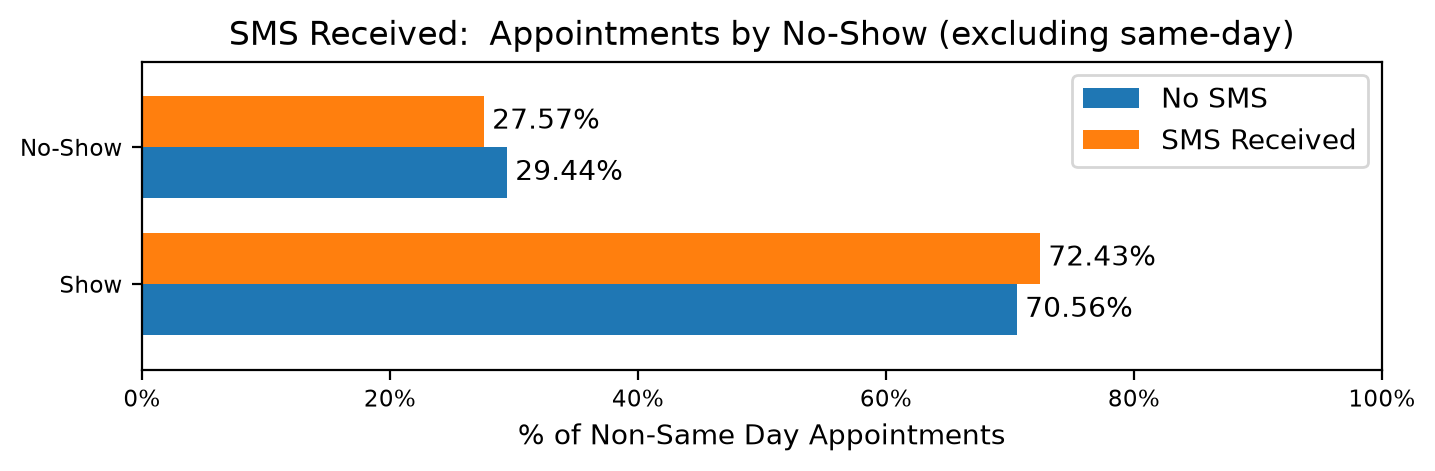

Optimization terminated successfully.
         Current function value: 0.597576
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 NoShow   No. Observations:                71959
Model:                          Logit   Df Residuals:                    71957
Method:                           MLE   Df Model:                            1
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:               0.0003561
Time:                        16:03:20   Log-Likelihood:                -43001.
converged:                       True   LL-Null:                       -43016.
Covariance Type:            nonrobust   LLR p-value:                 3.109e-08
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       -0.8742      0.011    -76.097      0.000      -0.897      -0.852
SMS_received    -0.0914

,p_value,coef
variable,,
SMS_received,0.0000,-0.0914


In [44]:
print("\nSame day")
print(f"{'All':<20}{df_same_day_appointments.shape[0]}")
print(
    f"{'SMS_received':<20}{df_same_day_appointments.query('SMS_received == True').shape[0]}"
)
print(
    f"{'No SMS':<20}{df_same_day_appointments.query('SMS_received == False').shape[0]}"
)

df_all_appointments_excl_sameday = df_all_appointments.query("num_days > 0")

ax_no_show_by_sms = graph_distributions(
    data=compute_distributions(
        data=df_all_appointments_excl_sameday,
        group_queries={
            "No SMS": "SMS_received == False",
            "SMS Received": "SMS_received == True",
        },
        sub_queries={
            "Show": "NoShow == False",
            "No-Show": "NoShow == True",
        },
    ),
    x_label="% of Non-Same Day Appointments",
)
ax_no_show_by_sms.set_title(
    "SMS Received:  Appointments by No-Show (excluding same-day)"
)

plt.show()


sms_model = sm.Logit(
    df_all_appointments_excl_sameday["NoShow"],
    df_all_appointments_excl_sameday[["intercept", "SMS_received"]],
)
sms_results = sms_model.fit()

print(sms_results.summary())
print("\nexplanatory variables")
explanatory_variables(sms_results).style.format(precision=4)

__Appointment num_days distribution by SMS_received__

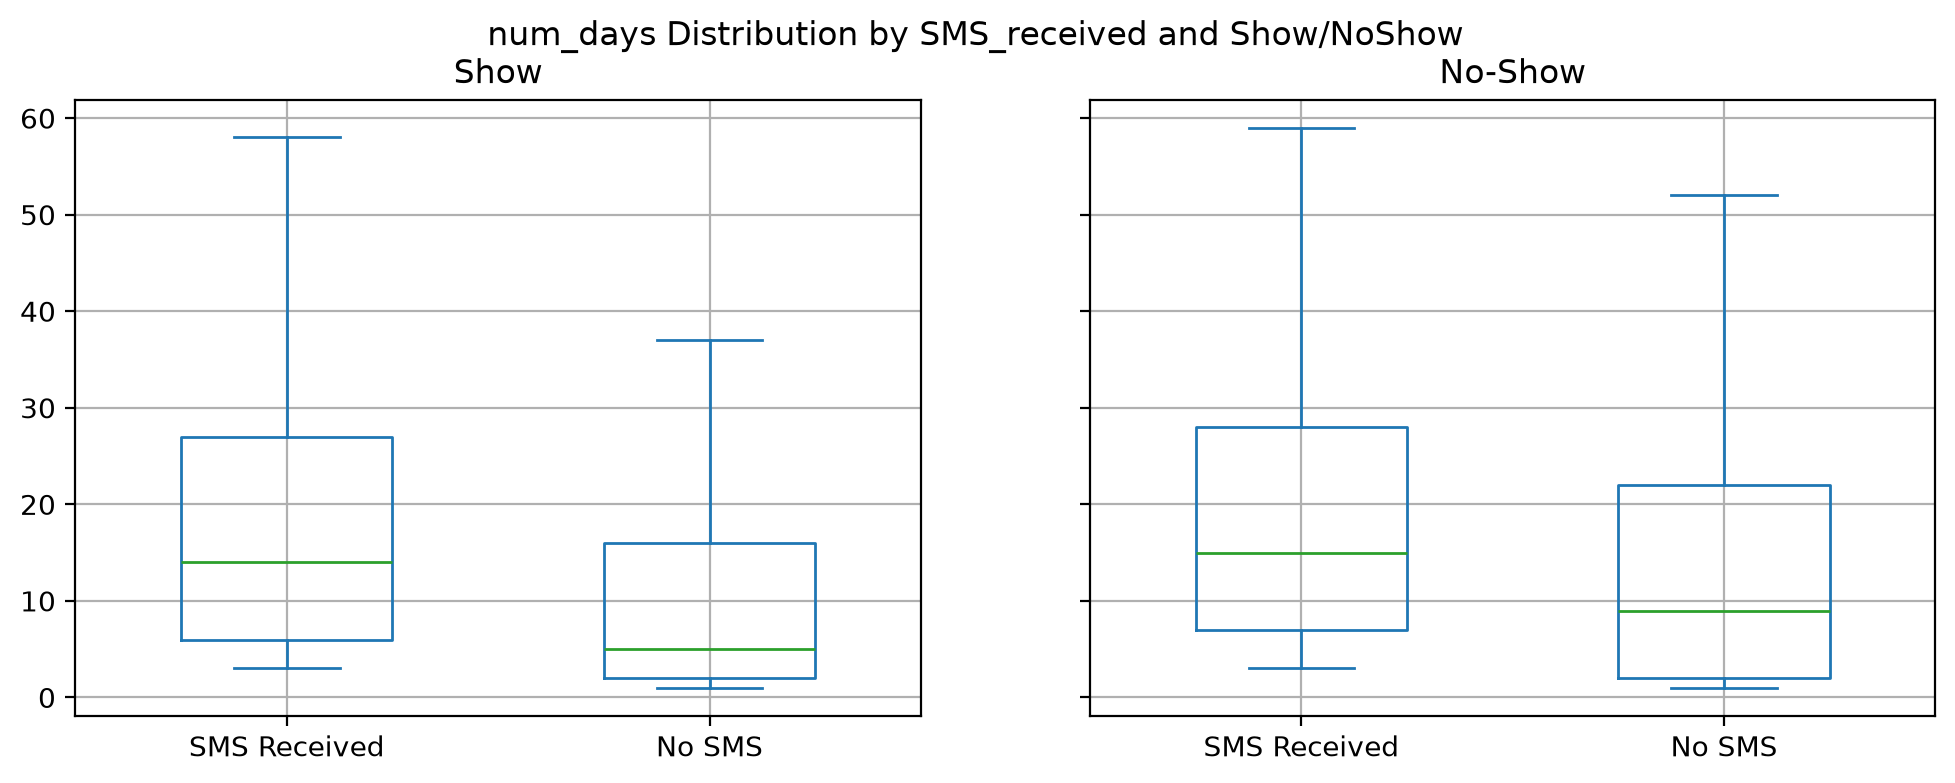

In [45]:
df_all_apt_sms = df_all_appointments_excl_sameday.query("SMS_received == True")
num_days_sms_no_show = df_all_apt_sms.query("NoShow == True")["num_days"]
num_days_sms_show = df_all_apt_sms.query("NoShow == False")["num_days"]

df_all_apt_no_sms = df_all_appointments_excl_sameday.query("SMS_received == False")
num_days_no_sms_no_show = df_all_apt_no_sms.query("NoShow == True")["num_days"]
num_days_no_sms_show = df_all_apt_no_sms.query("NoShow == False")["num_days"]

df_num_days_no_show_dist = pd.DataFrame(
    {
        "SMS Received": num_days_sms_no_show,
        "No SMS": num_days_no_sms_no_show,
    }
)

df_num_days_show_dist = pd.DataFrame(
    {
        "SMS Received": num_days_sms_show,
        "No SMS": num_days_no_sms_show,
    }
)

num_days_sms_fig, num_days_sms_axs = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [1, 1]},
    constrained_layout=False,
    sharey=True,
)

num_days_sms_fig.suptitle("num_days Distribution by SMS_received and Show/NoShow")

ax_num_days_show_dist = df_num_days_show_dist.plot.box(
    grid=True,
    widths=0.5,
    flierprops={
        "marker": "o",
        "markerfacecolor": "tab:blue",
        "markeredgecolor": "tab:blue",
        "markersize": 5,
        "alpha": 0.1,
    },
    showfliers=False,
    ax=num_days_sms_axs[0],
)
ax_num_days_show_dist.set_title("Show")

ax_num_days_no_show_dist = df_num_days_no_show_dist.plot.box(
    grid=True,
    widths=0.5,
    flierprops={
        "marker": "o",
        "markerfacecolor": "tab:blue",
        "markeredgecolor": "tab:blue",
        "markersize": 5,
        "alpha": 0.1,
    },
    showfliers=False,
    ax=num_days_sms_axs[1],
)
ax_num_days_no_show_dist.set_title("No-Show")

plt.show()

In [46]:
df_num_days_no_show_dist_sms_describe = df_num_days_no_show_dist[
    "SMS Received"
].describe()
df_num_days_no_show_dist_no_sms_describe = df_num_days_no_show_dist["No SMS"].describe()
df_num_days_show_dist_sms_describe = df_num_days_show_dist["SMS Received"].describe()
df_num_days_show_dist_no_sms_describe = df_num_days_show_dist["No SMS"].describe()

df_num_days_sms_describe = pd.DataFrame(
    {
        "SMS, No-Show": df_num_days_no_show_dist_sms_describe,
        "SMS, Show": df_num_days_show_dist_sms_describe,
        "NoSMS, No-Show": df_num_days_no_show_dist_no_sms_describe,
        "NoSMS, Show": df_num_days_show_dist_no_sms_describe,
    }
)

df_num_days_sms_describe.T.style.format(precision=4).set_caption(
    "Appointment num_days Distribution for SMS Received by Show/NoShow"
)

,count,mean,std,min,25%,50%,75%,max
"SMS, No-Show",9784.0000,20.0074,16.9717,3.0000,7.0000,15.0000,28.0000,179.0000
"SMS, Show",25698.0000,18.6395,16.9665,3.0000,6.0000,14.0000,27.0000,179.0000
"NoSMS, No-Show",10738.0000,14.6769,15.8599,1.0000,2.0000,9.0000,22.0000,179.0000
"NoSMS, Show",25739.0000,11.3925,14.9716,1.0000,2.0000,5.0000,16.0000,179.0000


#### Question 2: Conclusions

Several appointment-related factors were statistically associated with no-show status:

1. Appointment day of week was significant overall. Compared with Monday, Wednesday and Thursday were associated with lower odds of a no-show.
2. Longer scheduling-to-appointment intervals were associated with higher odds of a no-show.
3. Among non-same-day appointments, receiving an SMS reminder was associated with lower odds of a no-show.

A cursory examination suggests that the relationship between lead time and no-show status may differ by SMS status; this warrants further investigation.

<a id='conclusions'></a>
## Conclusions

When analyzing the data from [Kaggle: Medical Appointment No-Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments), the data points fell into two main categories:

### Health and demographic information about the patient

- `Gender`
- `Age`
- `Neighborhood`
- `FinancialAssistance` - patient enrolled in financial assistance program
- `Hypertension`
- `Diabetes`
- `Alcoholism`
- `NumHandicaps` - number of handicaps reported by patient

### Logistical information about the appointment

  - `SchedulingDate_day_name` - day of week
  - `AppointmentDate_day_name` - day of week
  - `num_days` - number of days between `SchedulingDate` and `AppointmentDate`
  - `SMS_received` - was an SMS reminder sent to the patient for the appointment?

### Results

A Patient's health and demographic factors showed some positive and negative associations with patients’ no-show rates, but the OLS models had consistently low R-squared values, indicating limited explanatory power.

A few of the data points regarding appointment logistics showed statistically significant negative associations with the no-show status of an appointment. Stated more plainly, they were associated with lower odds of a missed appointment.

- Appointment day of week (`AppointmentDate_day_name`) of Wednesday and Thursday, compared with Monday
- SMS reminder messages (`SMS_received`) for non-same day appointments

Scheduling day of week (`SchedulingDate_day_name`) was not significant overall, despite Friday showing a positive association compared to Monday.

`num_days` showed a statistically positive assocation with no-show, meaning longer lead times are associated with higher odds of a missed appointment.

### Caveats

Synergistic relationships between health, demographic, or logistic factors may exist, but were unexplored here with the exception of a cursory investigation of possible relationships between `num_days` and `SMS_received`. Evidence to support further investigation was found in that case.

In some cases, sparsity of data may have negative effects on the quality of the regression models, specifically `Neighborhood` and `NumHandicaps`

Finally, I have limited my selection of regression models to ones I have experience with in my coursework. Other models may exist that would produce superior results.


In [47]:
# Running this cell will execute a bash command to convert this notebook to an .html file
#!python -m nbconvert --to html Investigate_a_Dataset.ipynb